# Chapter 39: Camera Modeling and Calibration

This notebook is a compact executable companion to MIT Vision Book Chapter 39.
It keeps the chapter's original structure, displays every official MIT figure from the
MIT Vision Book directly in the notebook, and adds a small number of deterministic
CPU-friendly visualizations to make the geometry concrete.


In [1]:
import io
import json
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib import colors as mcolors
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

SEED = 39
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "index.ipynb").exists():
    candidate = NOTEBOOK_DIR / "notebooks" / "CV" / "2026" / "spring" / "final" / "chapter-39-camera-modeling"
    if candidate.exists():
        NOTEBOOK_DIR = candidate.resolve()
    else:
        matches = list(NOTEBOOK_DIR.rglob("chapter-39-camera-modeling/index.ipynb"))
        assert matches, f"Could not resolve the chapter directory from {Path.cwd()}"
        NOTEBOOK_DIR = matches[0].parent.resolve()

CHAPTER_DIR = NOTEBOOK_DIR

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f8fafc",
        "axes.edgecolor": "#334155",
        "axes.labelcolor": "#0f172a",
        "axes.titlecolor": "#0f172a",
        "xtick.color": "#334155",
        "ytick.color": "#334155",
        "font.size": 11,
        "axes.grid": False,
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#cbd5e1",
        "grid.color": "#cbd5e1",
        "grid.alpha": 0.45,
    }
)

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "vermillion": "#D55E00",
    "purple": "#CC79A7",
    "gray": "#475569",
    "light": "#94a3b8",
}


def savefig(fig, filename: str) -> None:
    del filename
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=180, bbox_inches="tight")
    buffer.seek(0)
    display(IPyImage(data=buffer.getvalue()))
    plt.close(fig)


def homogenize(points: torch.Tensor) -> torch.Tensor:
    ones = torch.ones((points.shape[0], 1), dtype=points.dtype)
    return torch.cat([points, ones], dim=1)


def rotation_x(angle_deg: float) -> torch.Tensor:
    t = math.radians(angle_deg)
    c, s = math.cos(t), math.sin(t)
    return torch.tensor([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]], dtype=torch.float64)


def rotation_y(angle_deg: float) -> torch.Tensor:
    t = math.radians(angle_deg)
    c, s = math.cos(t), math.sin(t)
    return torch.tensor([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]], dtype=torch.float64)


def make_intrinsics(fx: float, fy: float, cx: float, cy: float) -> torch.Tensor:
    return torch.tensor([[fx, 0.0, cx], [0.0, fy, cy], [0.0, 0.0, 1.0]], dtype=torch.float64)


def project_points(points_world: torch.Tensor, K: torch.Tensor, R: torch.Tensor, T: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    points_cam = (R @ (points_world - T).T).T
    pixels_h = (K @ points_cam.T).T
    pixels = pixels_h[:, :2] / pixels_h[:, 2:].clamp_min(1e-9)
    return pixels, points_cam


def build_dlt_matrix(points_world: torch.Tensor, pixels: torch.Tensor) -> torch.Tensor:
    rows = []
    for P, p in zip(points_world, pixels, strict=True):
        X, Y, Z = [float(v) for v in P]
        x, y = [float(v) for v in p]
        rows.append([-X, -Y, -Z, -1.0, 0.0, 0.0, 0.0, 0.0, x * X, x * Y, x * Z, x])
        rows.append([0.0, 0.0, 0.0, 0.0, -X, -Y, -Z, -1.0, y * X, y * Y, y * Z, y])
    return torch.tensor(rows, dtype=torch.float64)


def estimate_projection_matrix_dlt(points_world: torch.Tensor, pixels: torch.Tensor) -> torch.Tensor:
    A = build_dlt_matrix(points_world, pixels)
    _, _, vh = torch.linalg.svd(A)
    M = vh[-1].reshape(3, 4)
    return M / torch.linalg.norm(M)


def project_with_matrix(points_world: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
    Xh = homogenize(points_world).T
    ph = (M @ Xh).T
    return ph[:, :2] / ph[:, 2:3].clamp_min(1e-9)


def light_grid(ax):
    ax.grid(True, linewidth=0.7, color="#cbd5e1", alpha=0.45)

from IPython.display import HTML, Image as IPyImage, display


def normalize_points_2d(points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    centroid = points.mean(axis=0)
    mean_distance = np.linalg.norm(points - centroid, axis=1).mean()
    scale = math.sqrt(2.0) / max(mean_distance, 1e-9)
    T = np.array(
        [
            [scale, 0.0, -scale * centroid[0]],
            [0.0, scale, -scale * centroid[1]],
            [0.0, 0.0, 1.0],
        ],
        dtype=np.float64,
    )
    points_h = np.concatenate([points, np.ones((points.shape[0], 1), dtype=np.float64)], axis=1)
    normalized = (T @ points_h.T).T
    return normalized[:, :2], T


def normalize_points_3d(points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    centroid = points.mean(axis=0)
    mean_distance = np.linalg.norm(points - centroid, axis=1).mean()
    scale = math.sqrt(3.0) / max(mean_distance, 1e-9)
    U = np.array(
        [
            [scale, 0.0, 0.0, -scale * centroid[0]],
            [0.0, scale, 0.0, -scale * centroid[1]],
            [0.0, 0.0, scale, -scale * centroid[2]],
            [0.0, 0.0, 0.0, 1.0],
        ],
        dtype=np.float64,
    )
    points_h = np.concatenate([points, np.ones((points.shape[0], 1), dtype=np.float64)], axis=1)
    normalized = (U @ points_h.T).T
    return normalized[:, :3], U


def build_dlt_matrix_numpy(points_world: np.ndarray, pixels: np.ndarray) -> np.ndarray:
    rows = []
    for point_world, pixel in zip(points_world, pixels, strict=True):
        X, Y, Z = point_world
        u, v = pixel
        rows.append([0.0, 0.0, 0.0, 0.0, -X, -Y, -Z, -1.0, v * X, v * Y, v * Z, v])
        rows.append([X, Y, Z, 1.0, 0.0, 0.0, 0.0, 0.0, -u * X, -u * Y, -u * Z, -u])
    return np.asarray(rows, dtype=np.float64)


def estimate_projection_matrix_normalized_dlt(points_world: np.ndarray, pixels: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    normalized_pixels, T = normalize_points_2d(pixels)
    normalized_world, U = normalize_points_3d(points_world)
    A = build_dlt_matrix_numpy(normalized_world, normalized_pixels)
    _, _, vh = np.linalg.svd(A)
    projection_normalized = vh[-1].reshape(3, 4)
    projection = np.linalg.inv(T) @ projection_normalized @ U
    projection = projection / np.linalg.norm(projection[2, :3])
    if projection[2, 3] > 0.0:
        projection = -projection
    return projection, A


def project_with_projection_matrix(points_world: np.ndarray, projection: np.ndarray) -> np.ndarray:
    points_h = np.concatenate([points_world, np.ones((points_world.shape[0], 1), dtype=np.float64)], axis=1)
    projected_h = (projection @ points_h.T).T
    return projected_h[:, :2] / projected_h[:, 2:3]


def rq_decomposition(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    q_matrix, r_matrix = np.linalg.qr(np.flipud(matrix).T)
    r_matrix = np.flipud(r_matrix.T)
    r_matrix = np.fliplr(r_matrix)
    q_matrix = q_matrix.T
    q_matrix = np.flipud(q_matrix)
    diagonal_signs = np.where(np.diag(r_matrix) >= 0.0, 1.0, -1.0)
    sign_matrix = np.diag(diagonal_signs)
    r_matrix = r_matrix @ sign_matrix
    q_matrix = sign_matrix @ q_matrix
    if np.linalg.det(q_matrix) < 0.0:
        sign_matrix = np.diag([1.0, 1.0, -1.0])
        r_matrix = r_matrix @ sign_matrix
        q_matrix = sign_matrix @ q_matrix
    return r_matrix, q_matrix


def decompose_projection_matrix(projection: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    camera_matrix = projection[:, :3]
    intrinsics, rotation = rq_decomposition(camera_matrix)
    sign_matrix = np.diag(
        [
            -1.0 if intrinsics[0, 0] < 0.0 else 1.0,
            -1.0 if intrinsics[1, 1] < 0.0 else 1.0,
            1.0,
        ]
    )
    intrinsics = intrinsics @ sign_matrix
    rotation = sign_matrix @ rotation
    intrinsics = intrinsics / intrinsics[2, 2]
    translation = np.linalg.solve(intrinsics, projection[:, 3])
    camera_center = -np.linalg.inv(camera_matrix) @ projection[:, 3]
    return intrinsics, rotation, translation, camera_center


def render_html_table(rows: list[dict[str, object]], headers: list[str]) -> None:
    def fmt(value: object) -> str:
        if isinstance(value, float):
            return f"{value:.2f}"
        return str(value)

    header_html = ''.join(
        f'<th style="border:1px solid #cbd5e1;padding:6px 8px;background:#e2e8f0;text-align:left;">{header}</th>'
        for header in headers
    )
    body_html = []
    for row in rows:
        cells = ''.join(
            f'<td style="border:1px solid #cbd5e1;padding:6px 8px;vertical-align:top;">{fmt(row[header])}</td>'
            for header in headers
        )
        body_html.append(f'<tr>{cells}</tr>')
    html = (
        '<table style="border-collapse:collapse;font-size:0.92rem;min-width:720px;">'
        f'<thead><tr>{header_html}</tr></thead>'
        f'<tbody>{"".join(body_html)}</tbody></table>'
    )
    display(HTML(html))


def set_axes_equal(ax) -> None:
    x_limits = np.array(ax.get_xlim3d(), dtype=np.float64)
    y_limits = np.array(ax.get_ylim3d(), dtype=np.float64)
    z_limits = np.array(ax.get_zlim3d(), dtype=np.float64)
    spans = np.array([x_limits[1] - x_limits[0], y_limits[1] - y_limits[0], z_limits[1] - z_limits[0]])
    centers = np.array([x_limits.mean(), y_limits.mean(), z_limits.mean()])
    radius = 0.5 * spans.max()
    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])


## 39.1 Introduction

Chapter 39 shifts from the simple pinhole stories of earlier chapters to a more useful
camera model: one that can describe where the camera sits in the world, how it is
oriented, and how 3D points become pixels.

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/world_and_camera_coordinates.png" alt="MIT Vision Book Figure 39.1" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.1, Figure 39.1. This original textbook figure contrasts a camera-centered frame with a world-centered frame. It matters here because the whole chapter is about moving between those frames cleanly.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/the_picture.png" alt="MIT Vision Book Figure 39.2" style="width: 38%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.1, Figure 39.2. This original textbook figure shows the image whose geometry the chapter later models. It matters because calibration always connects a real picture back to a 3D scene.</em></p>
</div>

The chapter's core idea is that calibration is about estimating the transformation from
world coordinates to image coordinates. Intrinsic parameters describe the camera itself.
Extrinsic parameters describe the camera's position and pose relative to the scene.


## 39.2 3D Camera Projections in Homogeneous Coordinates

Perspective projection contains a division by depth, which makes the equations awkward in
ordinary Euclidean coordinates. Homogeneous coordinates let us express the same mapping as
a matrix multiplication followed by a normalization step.

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/camera_centric.png" alt="MIT Vision Book Figure 39.3" style="width: 82%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.2, Figure 39.3. This original textbook figure shows how a 3D point projects through a pinhole onto the image plane. It matters because homogeneous coordinates re-express this geometry in matrix form.</em></p>
</div>

The point to keep in mind is that a 3D location `P = [X, Y, Z]^T` projects to image
coordinates roughly proportional to `X/Z` and `Y/Z`. Nearby points look larger because
dividing by a smaller depth amplifies the image coordinates.

### 39.2.1 Parallel Projection

Parallel projection removes that depth-dependent division. It is a simpler model that is
sometimes useful for distant scenes or for deriving intuition, but it does not capture
the foreshortening that real pinhole cameras produce.


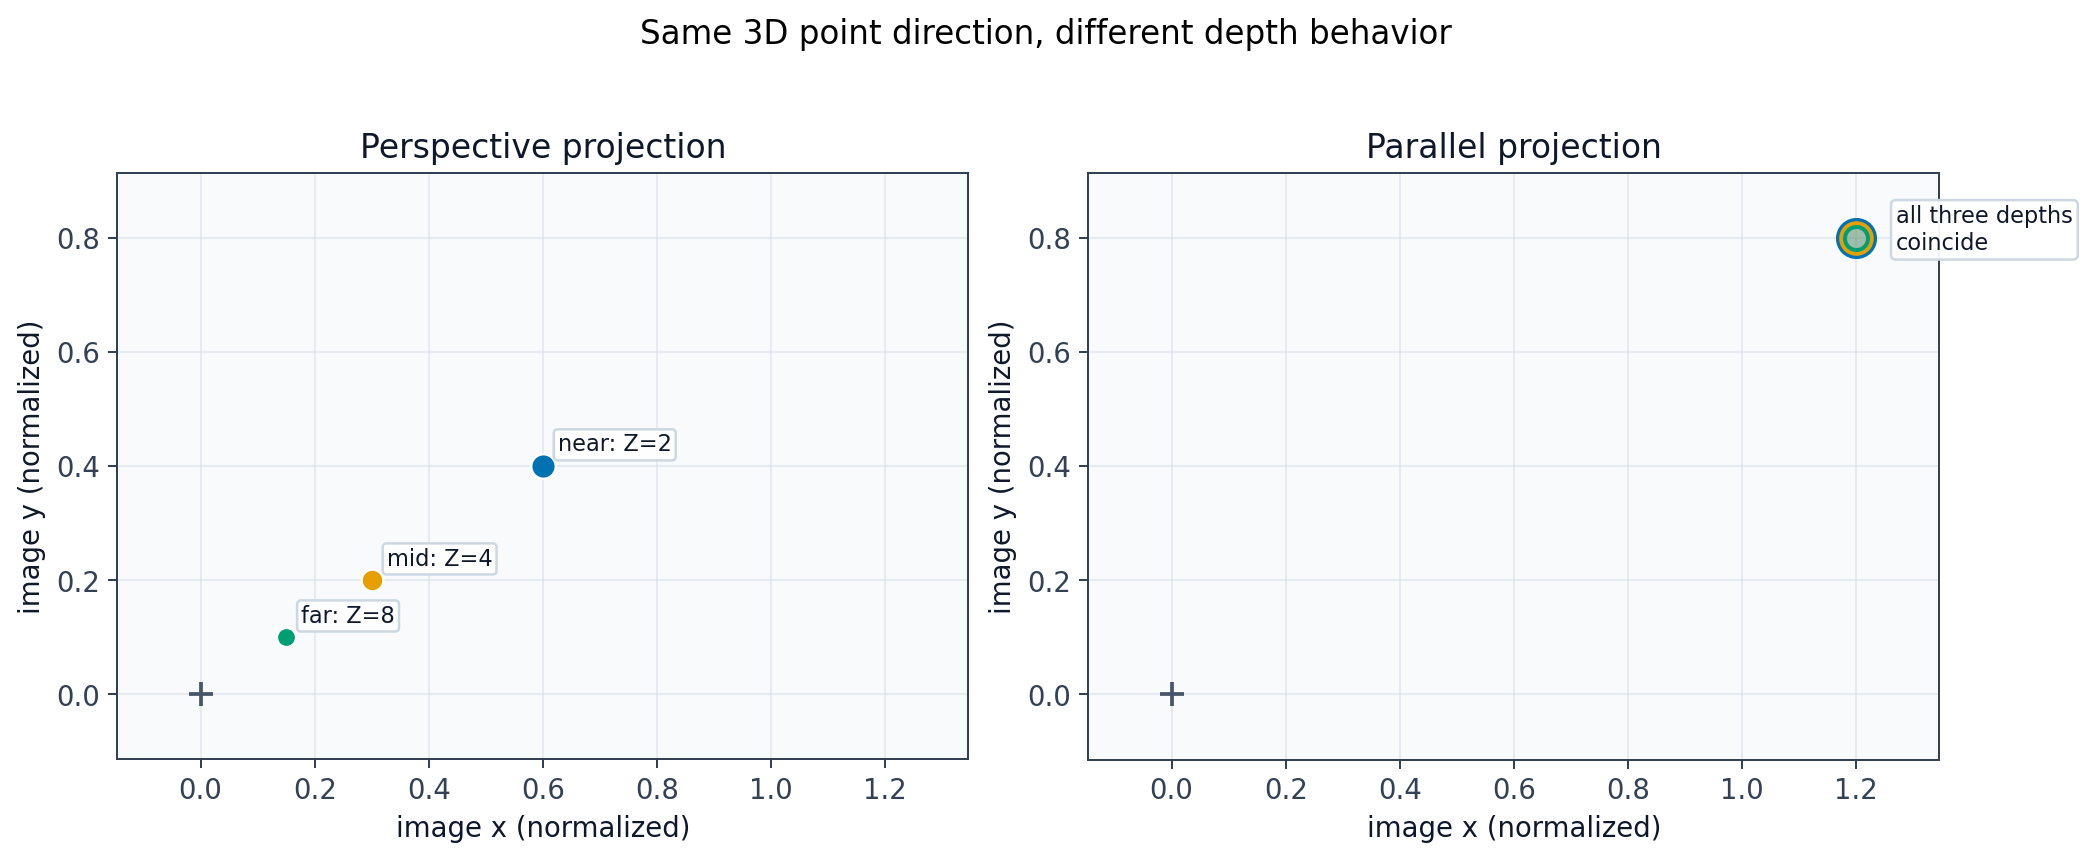

In [2]:
z_values = torch.tensor([2.0, 4.0, 8.0], dtype=torch.float64)
xy = torch.tensor([1.2, 0.8], dtype=torch.float64)
principal_point = torch.tensor([0.0, 0.0], dtype=torch.float64)
perspective_points = torch.stack([xy / z for z in z_values])
parallel_point = xy.clone()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)

labels = ["near", "mid", "far"]
colors = [COLORS["blue"], COLORS["orange"], COLORS["green"]]
marker_sizes = [95, 75, 58]

persp_all = torch.vstack([perspective_points, principal_point.unsqueeze(0)])
parallel_all = torch.vstack([parallel_point.unsqueeze(0), principal_point.unsqueeze(0)])
all_points = torch.vstack([persp_all, parallel_all])
pad_x = 0.08 * float(all_points[:, 0].max() - all_points[:, 0].min()) + 0.05
pad_y = 0.08 * float(all_points[:, 1].max() - all_points[:, 1].min()) + 0.05
xlim = (float(all_points[:, 0].min()) - pad_x, float(all_points[:, 0].max()) + pad_x)
ylim = (float(all_points[:, 1].min()) - pad_y, float(all_points[:, 1].max()) + pad_y)

ax = axes[0]
for point, depth, label, color, size in zip(perspective_points, z_values, labels, colors, marker_sizes, strict=True):
    ax.scatter(float(point[0]), float(point[1]), s=size, color=color, edgecolor="white", linewidth=0.9, zorder=3)
    ax.annotate(
        f"{label}: Z={depth:.0f}",
        xy=(float(point[0]), float(point[1])),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
        color="#0f172a",
        bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="#cbd5e1", alpha=0.95),
    )
ax.scatter(float(principal_point[0]), float(principal_point[1]), marker="+", s=90, color=COLORS["gray"], linewidth=1.5, zorder=4)
ax.set_title("Perspective projection")
ax.set_xlabel("image x (normalized)")
ax.set_ylabel("image y (normalized)")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="box")
light_grid(ax)

ax = axes[1]
for depth, color, size, alpha in zip(z_values, colors, [220, 150, 85], [0.32, 0.22, 0.12], strict=True):
    ax.scatter(
        float(parallel_point[0]),
        float(parallel_point[1]),
        s=size,
        facecolor=mcolors.to_rgba(color, alpha),
        edgecolor=color,
        linewidth=1.6,
        zorder=3,
        label=f"Z={depth:.0f}",
    )
ax.scatter(float(principal_point[0]), float(principal_point[1]), marker="+", s=90, color=COLORS["gray"], linewidth=1.5, zorder=4)
ax.text(
    float(parallel_point[0]) + 0.07,
    float(parallel_point[1]) - 0.02,
    "all three depths\ncoincide",
    fontsize=9,
    color="#0f172a",
    bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="#cbd5e1", alpha=0.95),
)
ax.set_title("Parallel projection")
ax.set_xlabel("image x (normalized)")
ax.set_ylabel("image y (normalized)")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="box")
light_grid(ax)

fig.suptitle("Same 3D point direction, different depth behavior", fontsize=13)
savefig(fig, "01-projection-models.png")


**Supplemental visualization for MIT Vision Book Section 39.2.**

We projected the same lateral 3D point at three depths using both perspective and parallel projection. The perspective panel shrinks image coordinates with increasing depth, while the parallel panel keeps them fixed. That is the key geometric difference between Sections 39.2 and 39.2.1.


## 39.3 Camera-Intrinsic Parameters

Intrinsic parameters describe how the camera turns rays into pixels. In practice, this
includes focal scaling, the principal point, and sometimes unequal pixel scales, skew,
or lens distortion.

### 39.3.1 From Meters to Pixels

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/pinhole_and_sensor.png" alt="MIT Vision Book Figure 39.4" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.3.1, Figure 39.4. This original textbook figure shows how focal length, sensor width, and pixel sampling connect physical geometry to image coordinates. It matters because intrinsic calibration lives in that conversion.</em></p>
</div>

The intrinsic matrix tells us how to convert camera-plane coordinates into pixel
coordinates. The chapter uses `a` and `b` for horizontal and vertical focal scaling, and
`(c_x, c_y)` for the principal point.

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/conventions_coordinates.png" alt="MIT Vision Book Figure 39.5" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.3.1, Figure 39.5. This original textbook figure compares common image-coordinate conventions. It matters because sign choices and origin placement change how we write the intrinsic matrix.</em></p>
</div>

In code, it is worth being explicit about conventions: image origins, axis directions,
and sign choices all affect the exact matrix form even when the geometry is the same.

### 39.3.2 From Pixels to Rays

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/light_ray.png" alt="MIT Vision Book Figure 39.6" style="width: 76%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.3.2, Figure 39.6. This original textbook figure shows that a single pixel defines a whole 3D ray, not a unique 3D point. It matters because depth is what turns that ray back into a specific scene location.</em></p>
</div>

Backprojection reverses the forward camera map only up to a ray. If a pixel is known and
the depth is unknown, there are infinitely many 3D points consistent with that pixel.

### 39.3.3 A Simple, although Unreliable, Calibration Method

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
<img src="https://visionbook.mit.edu/figures/imaging_geometry/simple_calibration_1.jpg" alt="MIT Vision Book Figure 39.7" style="width: 60%; max-width: 100%; height: auto;" />
<img src="https://visionbook.mit.edu/figures/imaging_geometry/simple_calibration_2.jpg" alt="MIT Vision Book Figure 39.7" style="width: 32%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.3.3, Figure 39.7. This original textbook figure groups the physical setup and the captured chessboard image. It matters because the chapter first introduces calibration as a measurement problem before presenting more general estimation methods.</em></p>
</div>

This sanity-check method uses a known target, a measured distance, and the apparent size
of the target in the image to estimate focal scaling. It is useful for intuition, but it
ignores many practical effects such as distortion and imperfect alignment.

### 39.3.4 Other Camera Parameters

Real cameras may also need skew terms, separate horizontal and vertical pixel scales, and
especially distortion correction. In practice, radial distortion is often the first extra
effect that visibly breaks the simplest pinhole model.


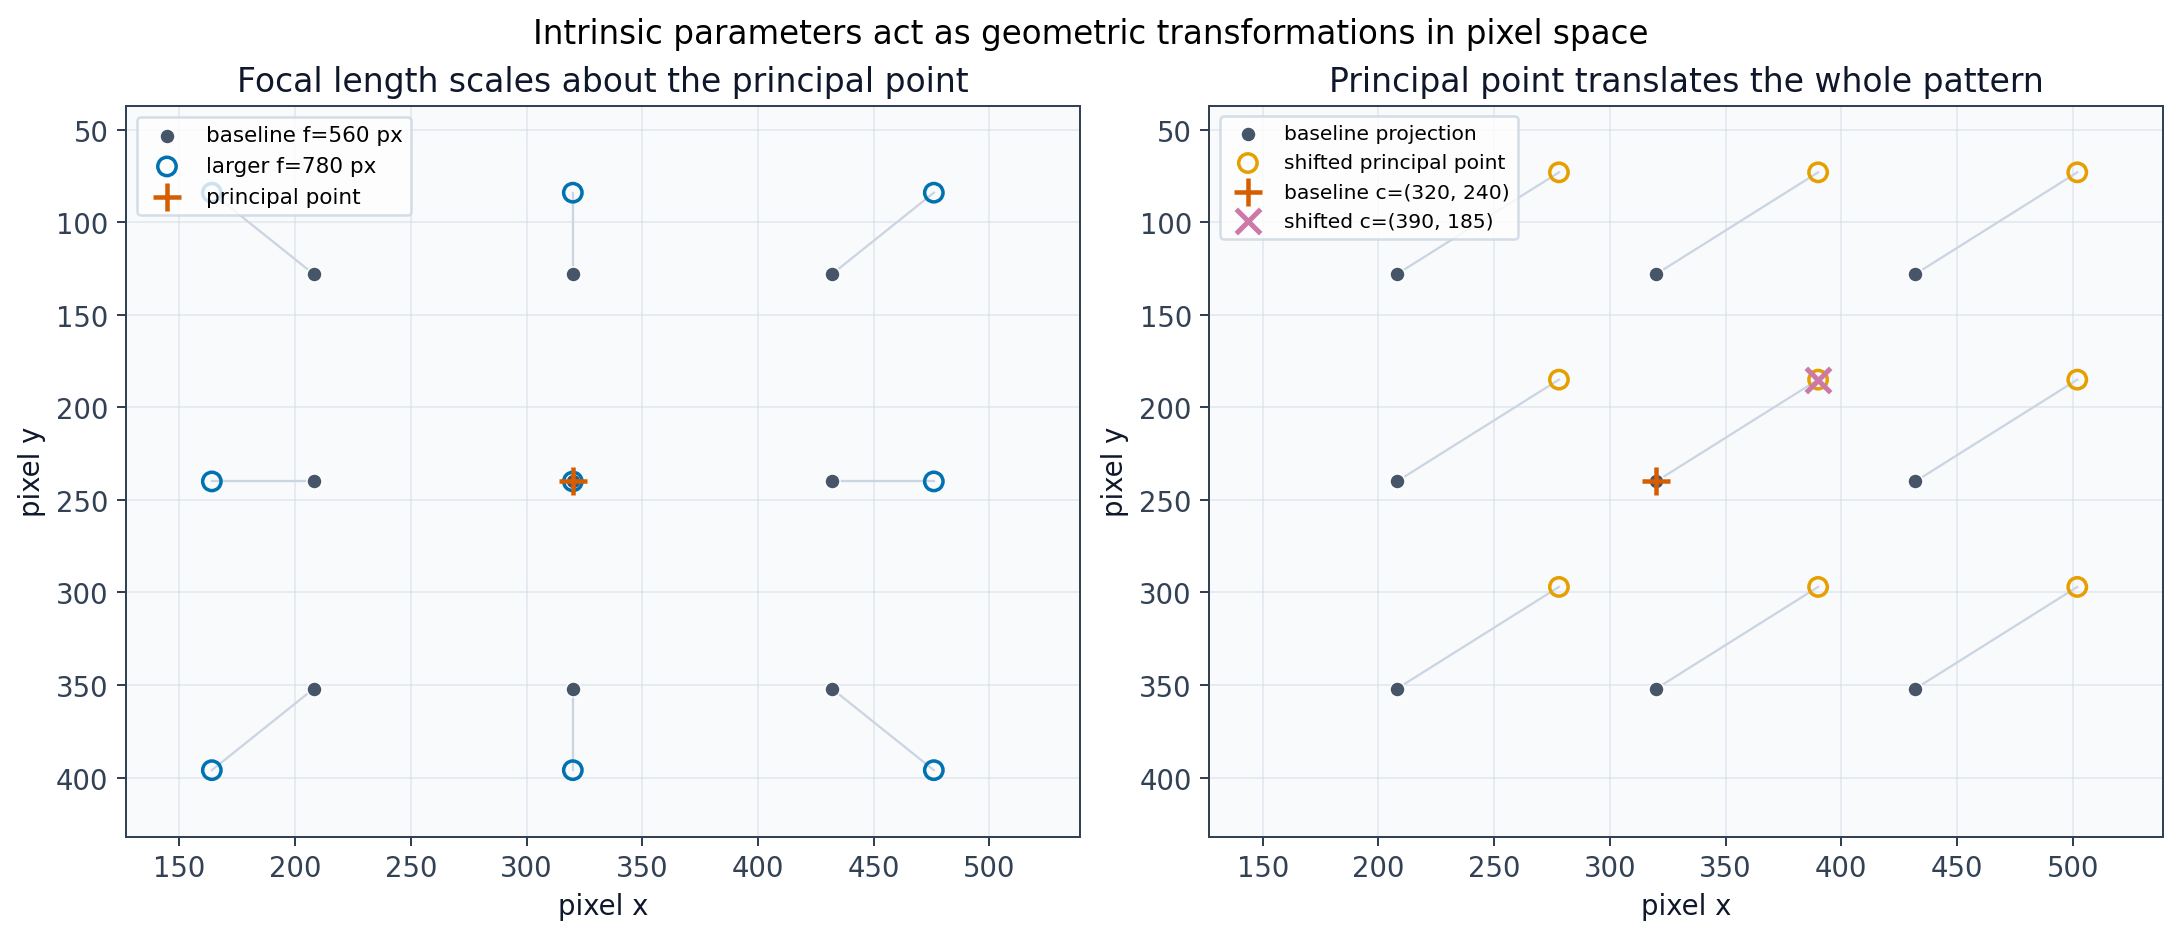

In [3]:
pattern_xy = torch.tensor(
    [
        [-0.9, -0.9], [0.0, -0.9], [0.9, -0.9],
        [-0.9,  0.0], [0.0,  0.0], [0.9,  0.0],
        [-0.9,  0.9], [0.0,  0.9], [0.9,  0.9],
    ],
    dtype=torch.float64,
)
pattern_depth = torch.full((pattern_xy.shape[0], 1), 4.5, dtype=torch.float64)
pattern_3d = torch.cat([pattern_xy, pattern_depth], dim=1)
K_base = make_intrinsics(560.0, 560.0, 320.0, 240.0)
K_focal = make_intrinsics(780.0, 780.0, 320.0, 240.0)
K_shift = make_intrinsics(560.0, 560.0, 390.0, 185.0)
R_eye = torch.eye(3, dtype=torch.float64)
T_zero = torch.zeros(3, dtype=torch.float64)

baseline_pixels, _ = project_points(pattern_3d, K_base, R_eye, T_zero)
focal_pixels, _ = project_points(pattern_3d, K_focal, R_eye, T_zero)
shift_pixels, _ = project_points(pattern_3d, K_shift, R_eye, T_zero)
principal_base = torch.tensor([320.0, 240.0], dtype=torch.float64)
principal_shift = torch.tensor([390.0, 185.0], dtype=torch.float64)

all_points = torch.vstack([baseline_pixels, focal_pixels, shift_pixels, principal_base.unsqueeze(0), principal_shift.unsqueeze(0)])
pad_x = 0.08 * float(all_points[:, 0].max() - all_points[:, 0].min()) + 10.0
pad_y = 0.08 * float(all_points[:, 1].max() - all_points[:, 1].min()) + 10.0
xlim = (float(all_points[:, 0].min()) - pad_x, float(all_points[:, 0].max()) + pad_x)
y_top = float(all_points[:, 1].min()) - pad_y
y_bottom = float(all_points[:, 1].max()) + pad_y

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.1), constrained_layout=True)

ax = axes[0]
for base_pt, changed_pt in zip(baseline_pixels, focal_pixels, strict=True):
    ax.plot([float(base_pt[0]), float(changed_pt[0])], [float(base_pt[1]), float(changed_pt[1])], color="#cbd5e1", lw=0.9, zorder=1)
ax.scatter(baseline_pixels[:, 0], baseline_pixels[:, 1], s=36, color=COLORS["gray"], edgecolor="white", linewidth=0.6, label="baseline f=560 px", zorder=3)
ax.scatter(focal_pixels[:, 0], focal_pixels[:, 1], s=54, facecolor="none", edgecolor=COLORS["blue"], linewidth=1.4, label="larger f=780 px", zorder=4)
ax.scatter([float(principal_base[0])], [float(principal_base[1])], marker="+", s=120, color=COLORS["vermillion"], linewidth=1.8, label="principal point", zorder=5)
ax.set_title("Focal length scales about the principal point")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.set_xlim(*xlim)
ax.set_ylim(y_bottom, y_top)
light_grid(ax)
ax.legend(loc="upper left", fontsize=8.6)

ax = axes[1]
for base_pt, changed_pt in zip(baseline_pixels, shift_pixels, strict=True):
    ax.plot([float(base_pt[0]), float(changed_pt[0])], [float(base_pt[1]), float(changed_pt[1])], color="#cbd5e1", lw=0.9, zorder=1)
ax.scatter(baseline_pixels[:, 0], baseline_pixels[:, 1], s=36, color=COLORS["gray"], edgecolor="white", linewidth=0.6, label="baseline projection", zorder=3)
ax.scatter(shift_pixels[:, 0], shift_pixels[:, 1], s=54, facecolor="none", edgecolor=COLORS["orange"], linewidth=1.4, label="shifted principal point", zorder=4)
ax.scatter([float(principal_base[0])], [float(principal_base[1])], marker="+", s=120, color=COLORS["vermillion"], linewidth=1.8, label="baseline c=(320, 240)", zorder=5)
ax.scatter([float(principal_shift[0])], [float(principal_shift[1])], marker="x", s=95, color=COLORS["purple"], linewidth=2.0, label="shifted c=(390, 185)", zorder=5)
ax.set_title("Principal point translates the whole pattern")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.set_xlim(*xlim)
ax.set_ylim(y_bottom, y_top)
light_grid(ax)
ax.legend(loc="upper left", fontsize=8.1)

fig.suptitle("Intrinsic parameters act as geometric transformations in pixel space", fontsize=13)
savefig(fig, "02-intrinsics-effects.png")


**Computational reconstruction related to MIT Vision Book Section 39.3, Figure 39.4.**

We projected the same nine 3D points while changing either focal scaling or the principal point. Larger focal length magnifies the image, while changing `(c_x, c_y)` translates all projected points together. Those are two of the central effects encoded by the intrinsic matrix.


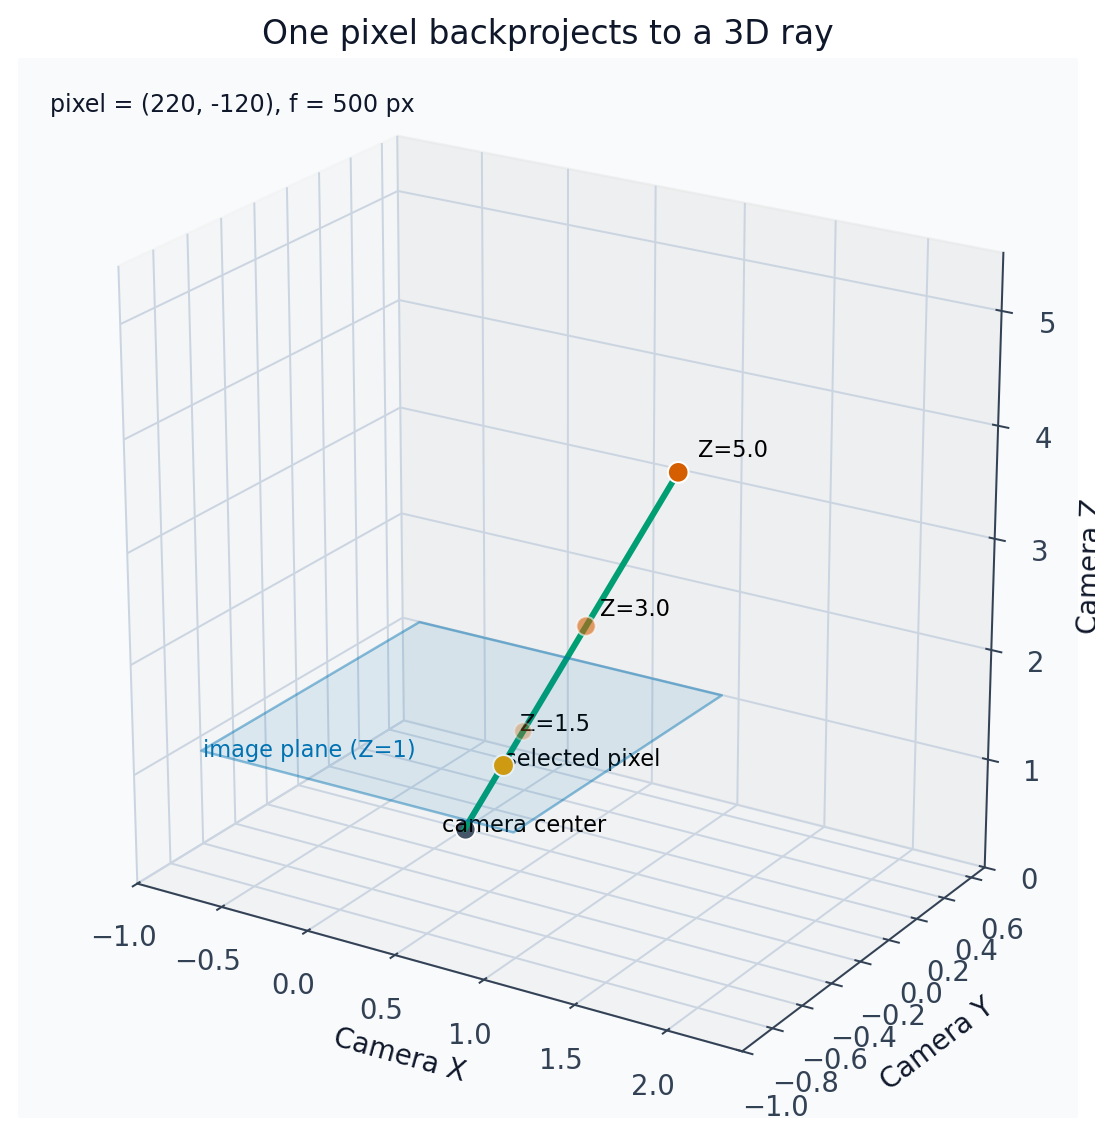

In [4]:
pixel = torch.tensor([220.0, -120.0], dtype=torch.float64)
focal = 500.0
depths = torch.tensor([1.5, 3.0, 5.0], dtype=torch.float64)
plane_depth = 1.0
pixel_on_plane = torch.tensor([pixel[0] / focal, pixel[1] / focal, plane_depth], dtype=torch.float64)
ray_dir = pixel_on_plane.clone()
ray_points = depths.unsqueeze(1) * ray_dir.unsqueeze(0)

plane_w, plane_h = 0.9, 0.7
plane_vertices = [
    [-plane_w, -plane_h, plane_depth],
    [ plane_w, -plane_h, plane_depth],
    [ plane_w,  plane_h, plane_depth],
    [-plane_w,  plane_h, plane_depth],
]

fig = plt.figure(figsize=(8.2, 6.2), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")
a = Poly3DCollection([plane_vertices], facecolors=mcolors.to_rgba(COLORS["blue"], 0.10), edgecolors=mcolors.to_rgba(COLORS["blue"], 0.45), linewidths=1.0)
ax.add_collection3d(a)
ax.plot([0.0, float(ray_points[-1, 0])], [0.0, float(ray_points[-1, 1])], [0.0, float(ray_points[-1, 2])], color=COLORS["green"], lw=2.4, zorder=3)
ax.scatter([0.0], [0.0], [0.0], color=COLORS["gray"], s=64, edgecolor="white", linewidth=0.7, zorder=5)
ax.scatter([float(pixel_on_plane[0])], [float(pixel_on_plane[1])], [plane_depth], color=COLORS["orange"], s=70, edgecolor="white", linewidth=0.8, zorder=6)
ax.scatter(ray_points[:, 0], ray_points[:, 1], ray_points[:, 2], color=COLORS["vermillion"], s=[48, 58, 68], edgecolor="white", linewidth=0.8, zorder=7)

label_offsets = [(0.05, -0.08, 0.10), (0.06, 0.02, 0.10), (0.05, 0.06, 0.10)]
for point, depth, (dx, dy, dz) in zip(ray_points, depths, label_offsets, strict=True):
    ax.text(float(point[0] + dx), float(point[1] + dy), float(point[2] + dz), f"Z={depth:.1f}", fontsize=9)

ax.text2D(0.03, 0.95, "pixel = (220, -120), f = 500 px", transform=ax.transAxes, fontsize=9.5, color="#0f172a")
ax.text(float(pixel_on_plane[0] + 0.04), float(pixel_on_plane[1] - 0.03), float(pixel_on_plane[2] + 0.04), "selected pixel", fontsize=9)
ax.text(-0.08, -0.06, 0.0, "camera center", fontsize=9)
ax.text(-0.83, -0.76, plane_depth + 0.03, "image plane (Z=1)", fontsize=9, color=COLORS["blue"])
ax.set_title("One pixel backprojects to a 3D ray")
ax.set_xlabel("Camera X")
ax.set_ylabel("Camera Y")
ax.set_zlabel("Camera Z")
ax.set_xlim(-1.0, 2.4)
ax.set_ylim(-1.0, 0.7)
ax.set_zlim(0.0, 5.5)
ax.set_box_aspect((1.45, 1.0, 1.35))
ax.view_init(elev=22, azim=-58)
savefig(fig, "03-pixel-to-ray-backprojection.png")


**Computational reconstruction related to MIT Vision Book Section 39.3.2, Figure 39.6.**

We chose one pixel direction and sampled three depths along its backprojected ray. The computed points all correspond to the same image location, which is exactly why a pixel alone is insufficient to recover a unique 3D point.


## 39.4 Camera-Extrinsic Parameters

Extrinsic parameters answer a different question from intrinsics: where is the camera in
the world, and how is it rotated relative to the world frame?

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/world_and_camera_coordinates_2.png" alt="MIT Vision Book Figure 39.8" style="width: 82%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.4, Figure 39.8. This original textbook figure shows the extrinsic relationship between the world frame and the camera frame. It matters because `R` and `T` explain where the camera is and how it is oriented.</em></p>
</div>

The chapter writes this mapping as a rotation followed by a translation in homogeneous
coordinates. Once points are expressed in the camera frame, the intrinsic matrix can
project them into the image.

## 39.5 Full Camera Model

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/summary_camera_model.png" alt="MIT Vision Book Figure 39.9" style="width: 82%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.5, Figure 39.9. This original textbook figure summarizes the full pipeline from world coordinates to camera coordinates to pixels. It matters because the projection matrix combines all of those steps.</em></p>
</div>

The full projection matrix composes intrinsics with extrinsics. In compact notation, the
camera matrix is often written as `M = K [R | -RT]`.

## 39.6 A Few Concrete Examples

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/camera_calibration_scenarios.png" alt="MIT Vision Book Figure 39.10" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.6, Figure 39.10. This original textbook figure collects the concrete camera-pose cases discussed in the chapter. It matters because the same matrix model can represent all of them.</em></p>
</div>

The chapter then walks through level cameras, tilted cameras, and more structured ground
scenes to show how pose affects the final image equations.

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/horizon_heads.jpg" alt="MIT Vision Book Figure 39.11" style="width: 62%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.6, Figure 39.11. This original textbook figure shows a practical horizon cue in a level camera. It matters because camera orientation leaves visible traces in ordinary photographs.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/eyes_location.png" alt="MIT Vision Book Figure 39.12" style="width: 92%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.6, Figure 39.12. This original textbook figure sketches why equal-height points can line up in the image despite being at different depths. It matters because the horizon is a geometric consequence of camera pose.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
<img src="https://visionbook.mit.edu/figures/imaging_geometry/low_horizon_vp.jpg" alt="MIT Vision Book Figure 39.13" style="width: 48%; max-width: 100%; height: auto;" />
<img src="https://visionbook.mit.edu/figures/imaging_geometry/high_horizon_vp.jpg" alt="MIT Vision Book Figure 39.13" style="width: 48%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.6, Figure 39.13. This original textbook figure groups two photos taken with different camera tilt angles. It matters because changing the camera pitch shifts the horizon line in a predictable way.</em></p>
</div>

A helpful way to read these examples is to ask which quantities stay fixed when the
camera tilts or translates. Horizon-line motion is especially useful because it gives a
visible signature of camera pitch.


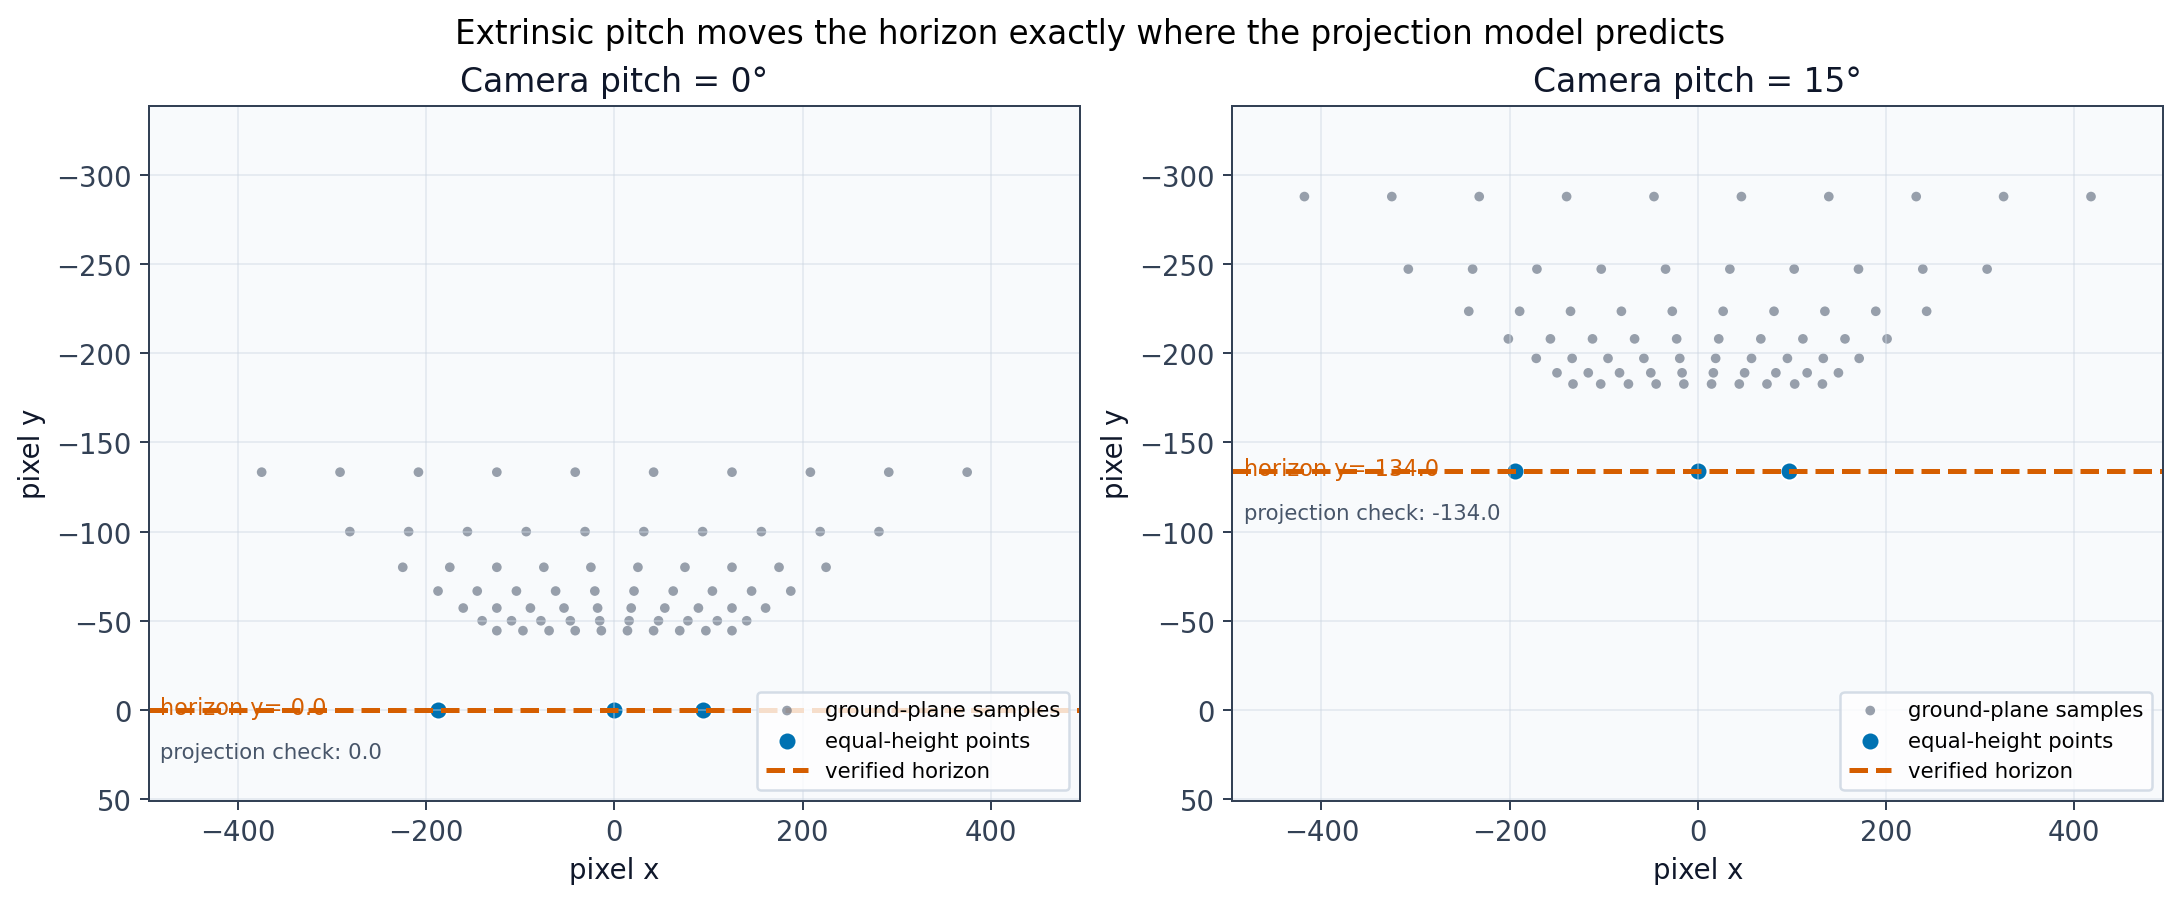

In [5]:
K = make_intrinsics(500.0, 500.0, 0.0, 0.0)
T = torch.tensor([0.0, 1.6, 0.0], dtype=torch.float64)
pitches = [0.0, 15.0]

ground_x = torch.linspace(-4.5, 4.5, 10, dtype=torch.float64)
ground_z = torch.linspace(6.0, 18.0, 7, dtype=torch.float64)
ground_points = torch.tensor([[float(x), 0.0, float(z)] for z in ground_z for x in ground_x], dtype=torch.float64)
horizon_points = torch.tensor([[float(x), float(T[1]), 1500.0] for x in torch.linspace(-6.0, 6.0, 13, dtype=torch.float64)], dtype=torch.float64)
reference_people = torch.tensor([[-3.0, float(T[1]), 8.0], [0.0, float(T[1]), 12.0], [3.0, float(T[1]), 16.0]], dtype=torch.float64)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.9), constrained_layout=True)
panel_data = []
for pitch in pitches:
    R = rotation_x(pitch)
    ground_pixels, _ = project_points(ground_points, K, R, T)
    equal_height_pixels, _ = project_points(reference_people, K, R, T)
    far_pixels, _ = project_points(horizon_points, K, R, T)
    horizon_y = float(far_pixels[:, 1].mean())
    verified_horizon_y = -float(K[1, 1]) * math.tan(math.radians(pitch))
    panel_data.append((pitch, ground_pixels, equal_height_pixels, horizon_y, verified_horizon_y))

all_x = torch.cat([item[1][:, 0] for item in panel_data] + [item[2][:, 0] for item in panel_data])
all_y = torch.cat(
    [item[1][:, 1] for item in panel_data]
    + [item[2][:, 1] for item in panel_data]
    + [torch.tensor([item[3], item[4]], dtype=torch.float64) for item in panel_data]
)
pad_x = 0.07 * float(all_x.max() - all_x.min()) + 18.0
pad_y = 0.10 * float(all_y.max() - all_y.min()) + 22.0
xlim = (float(all_x.min()) - pad_x, float(all_x.max()) + pad_x)
ylim = (float(all_y.min()) - pad_y, float(all_y.max()) + pad_y)

for ax, (pitch, ground_pixels, equal_height_pixels, horizon_y, verified_horizon_y) in zip(axes, panel_data, strict=True):
    ax.scatter(ground_pixels[:, 0], ground_pixels[:, 1], s=15, color=mcolors.to_rgba(COLORS["gray"], 0.55), edgecolor="none", label="ground-plane samples")
    ax.scatter(equal_height_pixels[:, 0], equal_height_pixels[:, 1], s=52, color=COLORS["blue"], edgecolor="white", linewidth=0.8, label="equal-height points")
    # With P_C = R(P_W - T), the implemented positive downward pitch places the horizon at y = -f tan(theta).
    ax.axhline(verified_horizon_y, color=COLORS["vermillion"], linestyle="--", lw=2.0, label="verified horizon")
    ax.text(xlim[0] + 12.0, verified_horizon_y - 8.0, f"horizon y={verified_horizon_y:.1f}", color=COLORS["vermillion"], fontsize=9, va="top")
    ax.text(xlim[0] + 12.0, verified_horizon_y + 18.0, f"projection check: {horizon_y:.1f}", color=COLORS["gray"], fontsize=8.5, va="top")
    ax.set_title(f"Camera pitch = {pitch:.0f}°")
    ax.set_xlabel("pixel x")
    ax.set_ylabel("pixel y")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.invert_yaxis()
    light_grid(ax)
    ax.legend(loc="lower right", fontsize=8.5)

fig.suptitle("Extrinsic pitch moves the horizon exactly where the projection model predicts", fontsize=13)
savefig(fig, "04-extrinsics-and-horizon.png")


**Supplemental visualization for MIT Vision Book Section 39.6.**

We projected a small set of equal-height scene points with a level camera and with a 15 degree downward pitch. The dashed line marks the numerically verified horizon height `y_h = -f tan(theta)` under the notebook convention `P_C = R(P_W - T)`, and the displayed image coordinates use the standard image convention where `y` increases downward.


## 39.7 Camera Calibration

Calibration estimates the mapping from known 3D scene points to observed 2D image
points. The chapter first introduces a linear estimate of the projection matrix and then
discusses how to recover more interpretable intrinsic and extrinsic parameters.

### 39.7.1 Direct Linear Transform

DLT solves for a projection matrix by stacking linear equations from several 3D-to-2D
correspondences. The result is determined only up to an overall scale, which is fine for
projective geometry.

### 39.7.2 Recovering Intrinsic and Extrinsic Camera Parameters

Once a projection matrix has been estimated, we still need to factor it into camera
intrinsics and pose. Conceptually, this means separating the left `3x3` calibration part
from the world-to-camera pose terms.

### 39.7.3 Multiplane Calibration Method

Multiplane calibration uses several views of a known planar target to stabilize the
parameter estimates. This is closer to what practical camera-calibration toolkits do.

### 39.7.4 Nonlinear Optimization by Minimizing Reprojection Error

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/reprojection_error.png" alt="MIT Vision Book Figure 39.14" style="width: 62%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.7.4, Figure 39.14. This original textbook figure shows reprojection error directly on the image plane. It matters because nonlinear refinement usually optimizes camera parameters by minimizing this quantity.</em></p>
</div>

Linear estimates are often only the starting point. A better model is usually obtained by
refining parameters to minimize the distance between observed image points and predicted
image points.

### 39.7.5 A Toy Example

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/office_with_measures_2.jpg" alt="MIT Vision Book Figure 39.15" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.7.5, Figure 39.15. This original textbook figure shows the real office scene used in the toy calibration example. It matters because the later 3D annotations are grounded in these measurements.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/correspondences_img.png" alt="MIT Vision Book Figure 39.16" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.7.5, Figure 39.16. This original textbook figure pairs image observations with measured 3D coordinates. It matters because calibration needs matched 3D scene points and 2D image points.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/result_toymodel_3dscene_and_estimated_camera_b.png" alt="MIT Vision Book Figure 39.17" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.7.5, Figure 39.17. This original textbook figure visualizes the inferred camera location from several viewpoints. It matters because a good calibration should produce a physically plausible camera pose.</em></p>
</div>

The office example shows the whole calibration story end to end: measure some 3D
positions, annotate the corresponding image points, estimate the camera, and then inspect
whether the result is plausible.


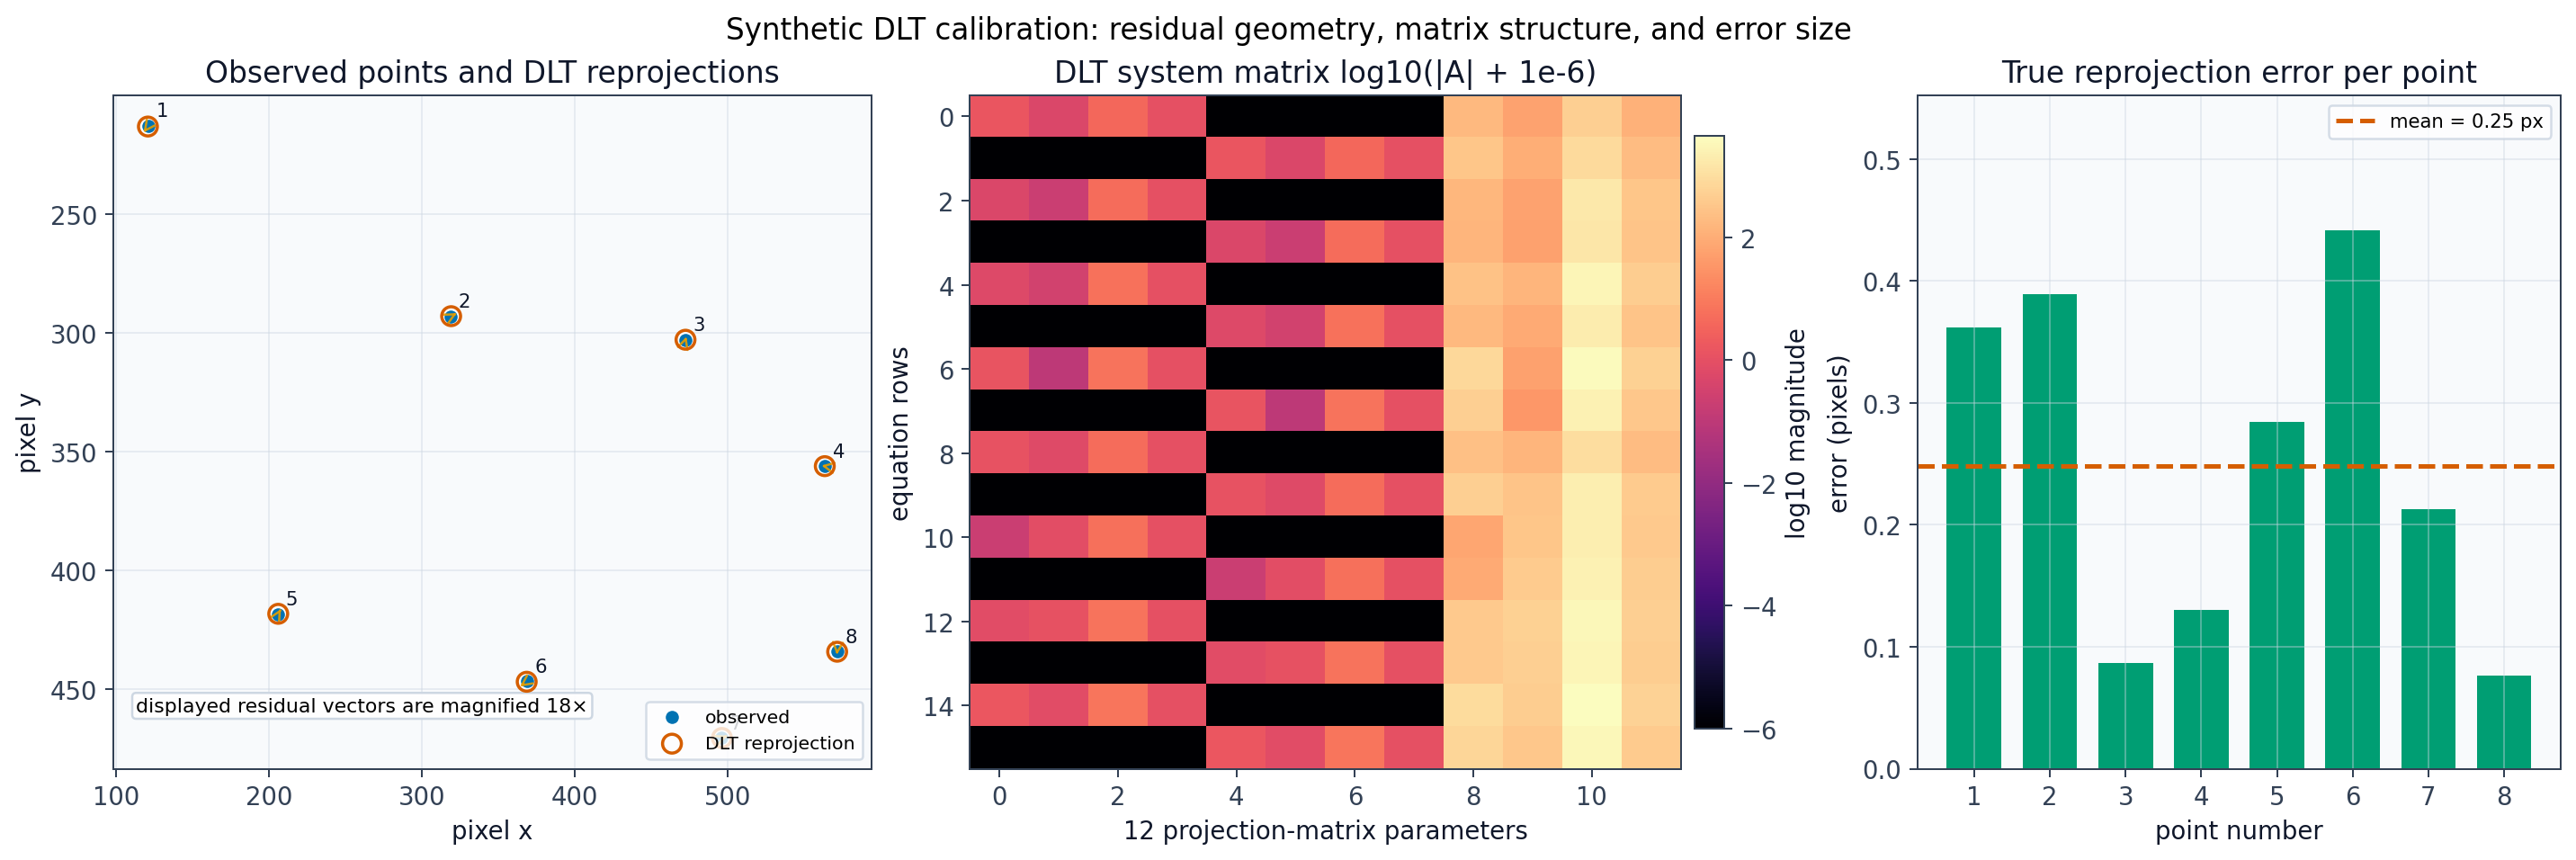

Estimated projection matrix (normalized):
tensor([[ 5.9194e-01, -7.8249e-02,  3.4478e-01, -7.8726e-02],
        [-4.3553e-02,  5.6133e-01,  3.2921e-01, -3.0505e-01],
        [-1.3287e-04, -1.7602e-04,  7.8526e-04,  3.0855e-04]],
       dtype=torch.float64)
Mean reprojection error: 0.248 px


In [6]:
world_points = torch.tensor(
    [
        [-1.5, -0.5,  4.0],
        [-0.5, -0.2,  5.2],
        [ 0.6, -0.3,  6.4],
        [ 1.4,  0.1,  7.0],
        [-1.2,  0.7,  5.0],
        [-0.2,  0.9,  6.0],
        [ 0.8,  1.1,  6.8],
        [ 1.6,  0.8,  8.0],
    ],
    dtype=torch.float64,
)

K_true = make_intrinsics(820.0, 790.0, 320.0, 240.0)
R_true = rotation_y(8.0) @ rotation_x(-12.0)
T_true = torch.tensor([0.3, 0.6, -0.4], dtype=torch.float64)

observed_pixels, _ = project_points(world_points, K_true, R_true, T_true)
noisy_pixels = observed_pixels + 0.8 * torch.tensor(
    [[0.5, -0.3], [-0.4, 0.2], [0.1, 0.4], [0.3, -0.5], [-0.2, 0.6], [0.4, -0.1], [-0.3, -0.2], [0.2, 0.3]],
    dtype=torch.float64,
)

M_est = estimate_projection_matrix_dlt(world_points, noisy_pixels)
reproj_clean = project_with_matrix(world_points, M_est)
reproj_error = torch.linalg.norm(reproj_clean - noisy_pixels, dim=1)
A = build_dlt_matrix(world_points, noisy_pixels)
A_display = torch.log10(A.abs() + 1e-6).numpy()
vector_scale = 18.0

fig, axes = plt.subplots(1, 3, figsize=(15.8, 5.2), constrained_layout=True, gridspec_kw={"width_ratios": [1.12, 1.05, 0.95]})

ax = axes[0]
ax.scatter(noisy_pixels[:, 0], noisy_pixels[:, 1], color=COLORS["blue"], s=44, edgecolor="white", linewidth=0.8, label="observed", zorder=3)
ax.scatter(reproj_clean[:, 0], reproj_clean[:, 1], facecolor="none", edgecolor=COLORS["vermillion"], s=70, linewidth=1.4, label="DLT reprojection", zorder=4)
for idx, (obs, pred) in enumerate(zip(noisy_pixels, reproj_clean, strict=True), start=1):
    delta = pred - obs
    vis_end = obs + vector_scale * delta
    ax.annotate("", xy=(float(vis_end[0]), float(vis_end[1])), xytext=(float(obs[0]), float(obs[1])), arrowprops=dict(arrowstyle="->", lw=1.0, color=COLORS["orange"], alpha=0.9))
    ax.text(float(obs[0]) + 5.0, float(obs[1]) - 4.0, str(idx), fontsize=8.5, color="#0f172a")
ax.text(0.03, 0.08, f"displayed residual vectors are magnified {vector_scale:.0f}×", transform=ax.transAxes, ha="left", va="bottom", fontsize=8.8, bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="#cbd5e1", alpha=0.95))
ax.set_title("Observed points and DLT reprojections")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.invert_yaxis()
light_grid(ax)
ax.legend(loc="lower right", fontsize=8.2)

ax = axes[1]
im = ax.imshow(A_display, aspect="auto", cmap="magma")
ax.set_title("DLT system matrix log10(|A| + 1e-6)")
ax.set_xlabel("12 projection-matrix parameters")
ax.set_ylabel("equation rows")
cbar = fig.colorbar(im, ax=ax, shrink=0.88, pad=0.02)
cbar.set_label("log10 magnitude", rotation=90)

ax = axes[2]
point_ids = torch.arange(1, len(reproj_error) + 1)
ax.bar(point_ids.numpy(), reproj_error.numpy(), color=COLORS["green"], width=0.72)
mean_error = float(reproj_error.mean())
ax.axhline(mean_error, color=COLORS["vermillion"], linestyle="--", lw=2.0, label=f"mean = {mean_error:.2f} px")
ax.set_title("True reprojection error per point")
ax.set_xlabel("point number")
ax.set_ylabel("error (pixels)")
ax.set_xticks(point_ids.numpy())
ax.set_ylim(0.0, max(float(reproj_error.max()) * 1.25, mean_error * 1.6))
light_grid(ax)
ax.legend(loc="upper right", fontsize=8.5)

fig.suptitle("Synthetic DLT calibration: residual geometry, matrix structure, and error size", fontsize=13)
savefig(fig, "05-dlt-reprojection-demo.png")

print("Estimated projection matrix (normalized):")
print(M_est)
print(f"Mean reprojection error: {reproj_error.mean().item():.3f} px")


**Computational reconstruction related to MIT Vision Book Section 39.7, Figure 39.14.**

We generated synthetic 3D points, projected them with a known camera, added small image noise, built the DLT linear system, and estimated a projection matrix up to scale. The left panel compares observed and predicted image points, the center panel shows the stacked DLT system, and the right panel summarizes reprojection error.


### Personal Toy Example: Measured Meeting-Room Calibration

This personal experiment mirrors the logic of MIT Figures 39.15–39.17 with a different scene: a meeting-room photograph taken by the notebook author, manual scene measurements in centimeters, manually identified `3D-2D` correspondences, normalized DLT camera estimation, reprojection validation, and measured-scene coordinate views.

The measured room is distinct from MIT's office example. The goal here is not to reproduce MIT's office data, but to follow the same measured-scene workflow with the same coordinate convention and visual logic as MIT Figure 39.16.

For this rebuild we adopt the MIT world-axis convention exactly:

- world-coordinate tuples are ordered as `(X_w, Y_w, Z_w)`;
- `Y_w` is the vertical height axis;
- `X_w` and `Z_w` lie on the floor;
- the floor plane is `X_w-Z_w` and therefore `Y_w = 0` on the floor;
- the blue wall is `X_w = 0`;
- the table top is `Y_w = 75 cm`.

The origin is the physical corner where the blue wall, the left jamb of the glass opening, and the floor meet. From that point:

- `+Y_w` goes upward along the opening jamb;
- `+Z_w` goes leftward along the blue wall toward the television and plant;
- `+X_w` goes outward from the blue wall into the room along the long direction of the table toward the photographer.


World coordinate convention for the measured scene:
- Origin O = opening-left floor corner = (0, 0, 0)
- +Y_w points upward along the opening-left jamb
- +Z_w points leftward along the blue wall toward the TV and plant
- +X_w points outward into the room toward the photographer
- blue wall: X_w = 0
- floor: Y_w = 0
- table top: Y_w = 75 cm
Measurement table used for the meeting-room model (centimeters):


measurement,value_cm,source segment,status
Blue-wall span from the yellow wall reference to the opening origin,193.00,Green 193 cm wall annotation,direct
Wall / opening height,300.00,Yellow 300 cm vertical annotation,direct
Opening width to the right of the origin,213.00,Brown 213 cm opening annotation,direct
Television width,148.00,Green 148 cm annotation along the TV lower edge,direct
Television bottom height,110.00,Magenta 110 cm annotation,direct
Television right gap inside the 193 cm wall span,22.50,Derived as (193 - 148) / 2 because the TV is centered in the measured wall span,derived
Television lower-left Z_w coordinate,170.50,Derived as 22.5 + 148.0 because +Z_w points leftward,derived
Television lower-right Z_w coordinate,22.50,Derived as the centered 22.5 cm right gap,derived
Table back-edge distance from the wall,98.00,Red 98 cm floor-depth annotation,direct
Table length along +X_w,240.00,Cyan 240 cm long-edge annotation,direct


Excluded or ambiguous measurements:
- The TV upper corners were excluded because the photograph does not provide an independently measured television height.
- The plant annotations 61 cm, 53 cm, and 28 cm were excluded because the planter corners are partially occluded and not reliable calibration points.
- The cyan 48 cm annotation was excluded because its upper endpoint is not an unambiguous architectural corner.
Point-by-point visual audit:
Point 1: origin wall/opening/floor corner — verified
Point 2: origin ceiling corner — verified
Point 3: left wall floor point — verified
Point 4: left wall ceiling point — verified
Point 5: TV lower-left corner — verified
Point 6: TV lower-right corner — verified
Point 7: opening-right floor corner — verified
Point 8: opening-right ceiling corner — verified
Point 9: table back-left top corner — verified
Point 10: table back-right top corner — verified
Point 11: table front-left top corner — verified
Point 12: table front-right top corner — exclu

i,feature,X_i,Y_i,Z_i,x_i,y_i,measurement source,direct / derived,retained / excluded
1,origin wall/opening/floor corner,0.00,0.00,0.00,498.0,551.0,architectural origin at the left opening jamb,direct,retained
2,origin ceiling corner,0.00,300.00,0.00,498.0,223.0,"same opening jamb, extended upward by the 300 cm wall height",derived,retained
3,left wall floor point,0.00,0.00,193.00,197.0,723.0,yellow-reference wall/floor point plus the measured 193 cm wall span,derived,retained
4,left wall ceiling point,0.00,300.00,193.00,166.0,184.0,yellow-reference wall/ceiling point plus the measured 193 cm wall span,derived,retained
5,TV lower-left corner,0.00,110.00,170.50,220.0,564.0,centered 148 cm TV width inside the 193 cm wall span,derived,retained
6,TV lower-right corner,0.00,110.00,22.50,458.0,553.0,centered 148 cm TV width inside the 193 cm wall span,derived,retained
7,opening-right floor corner,0.00,0.00,-213.00,854.0,579.0,architectural opening corner at the right jamb and floor,direct,retained
8,opening-right ceiling corner,0.00,300.00,-213.00,904.0,107.0,architectural opening corner at the right jamb and ceiling,direct,retained
9,table back-left top corner,98.00,75.00,123.00,322.0,633.0,"axis-aligned table model derived from the annotated 98, 240, 70, 120, and 75 cm measurements",derived,retained
10,table back-right top corner,98.00,75.00,3.00,555.0,617.0,"axis-aligned table model derived from the annotated 98, 240, 70, 120, and 75 cm measurements",derived,retained


Correspondence diagnostics:
- Number of retained points: 11
- Distinct supporting planes: 3 (blue wall (X_w = 0), floor (Y_w = 0), table top (Y_w = 75))
- 3D coordinate rank: 3
- DLT design-matrix rank: 12
- Coordinate ranges (cm): X_w in [0.0, 338.0], Y_w in [0.0, 300.0], Z_w in [-213.0, 193.0]
Estimated 3x4 projection matrix (normalized DLT):
[[ -606.9375   311.1504  2801.1648 -834892.4715]
 [ -949.0686  2643.5954  -395.9014 -1051294.6896]
 [    0.6741     0.7136     0.1904 -1655.5109]]
Recovered camera factors:
[[ 2861.7813   -44.9098   346.2692]
 [    0.0000  2583.3926  1171.3874]
 [    0.0000     0.0000     1.0000]]
[[    0.3042    -0.0334    -0.9520]
 [    0.6730    -0.6997     0.2396]
 [   -0.6741    -0.7136    -0.1904]]
translation vector t = [  -86.0317   343.7146 -1655.5109]
camera center C = [   1321.21     943.80     479.48] cm
rotation determinant = 1.000000
rotation orthogonality error = 3.427561e-16
estimated focal lengths: fx = 2861.78, fy = 2583.39
estimated principal 

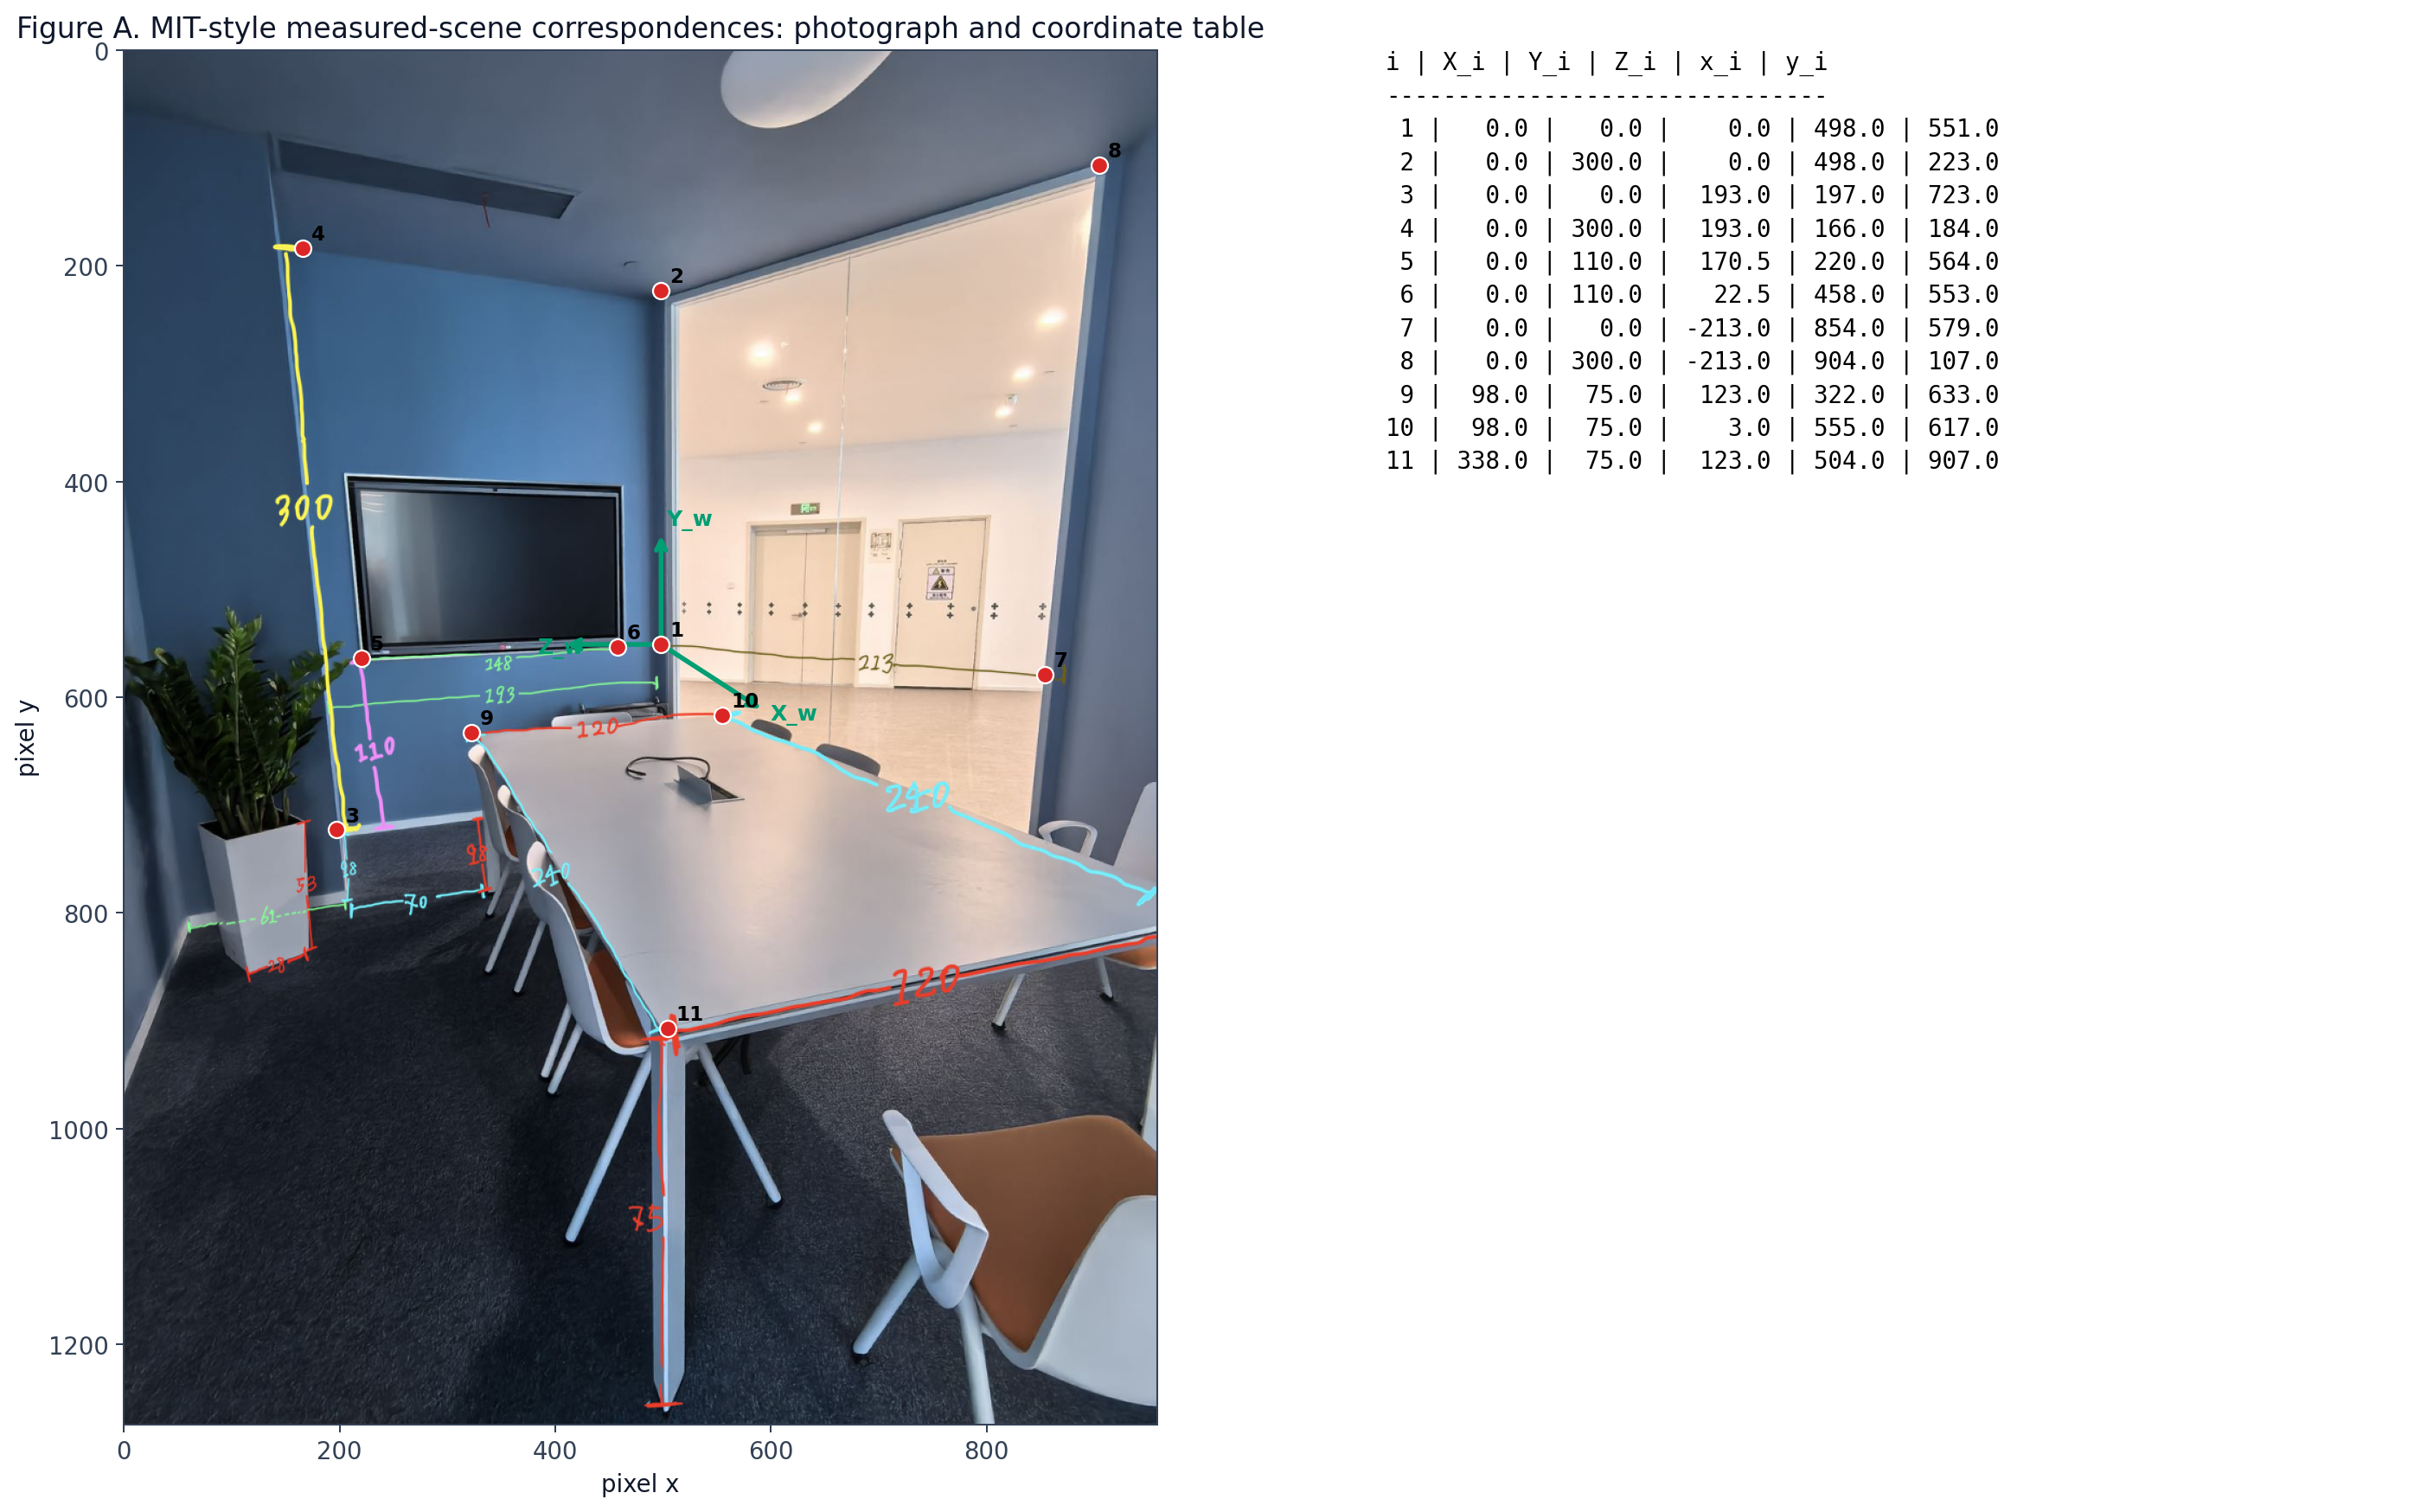

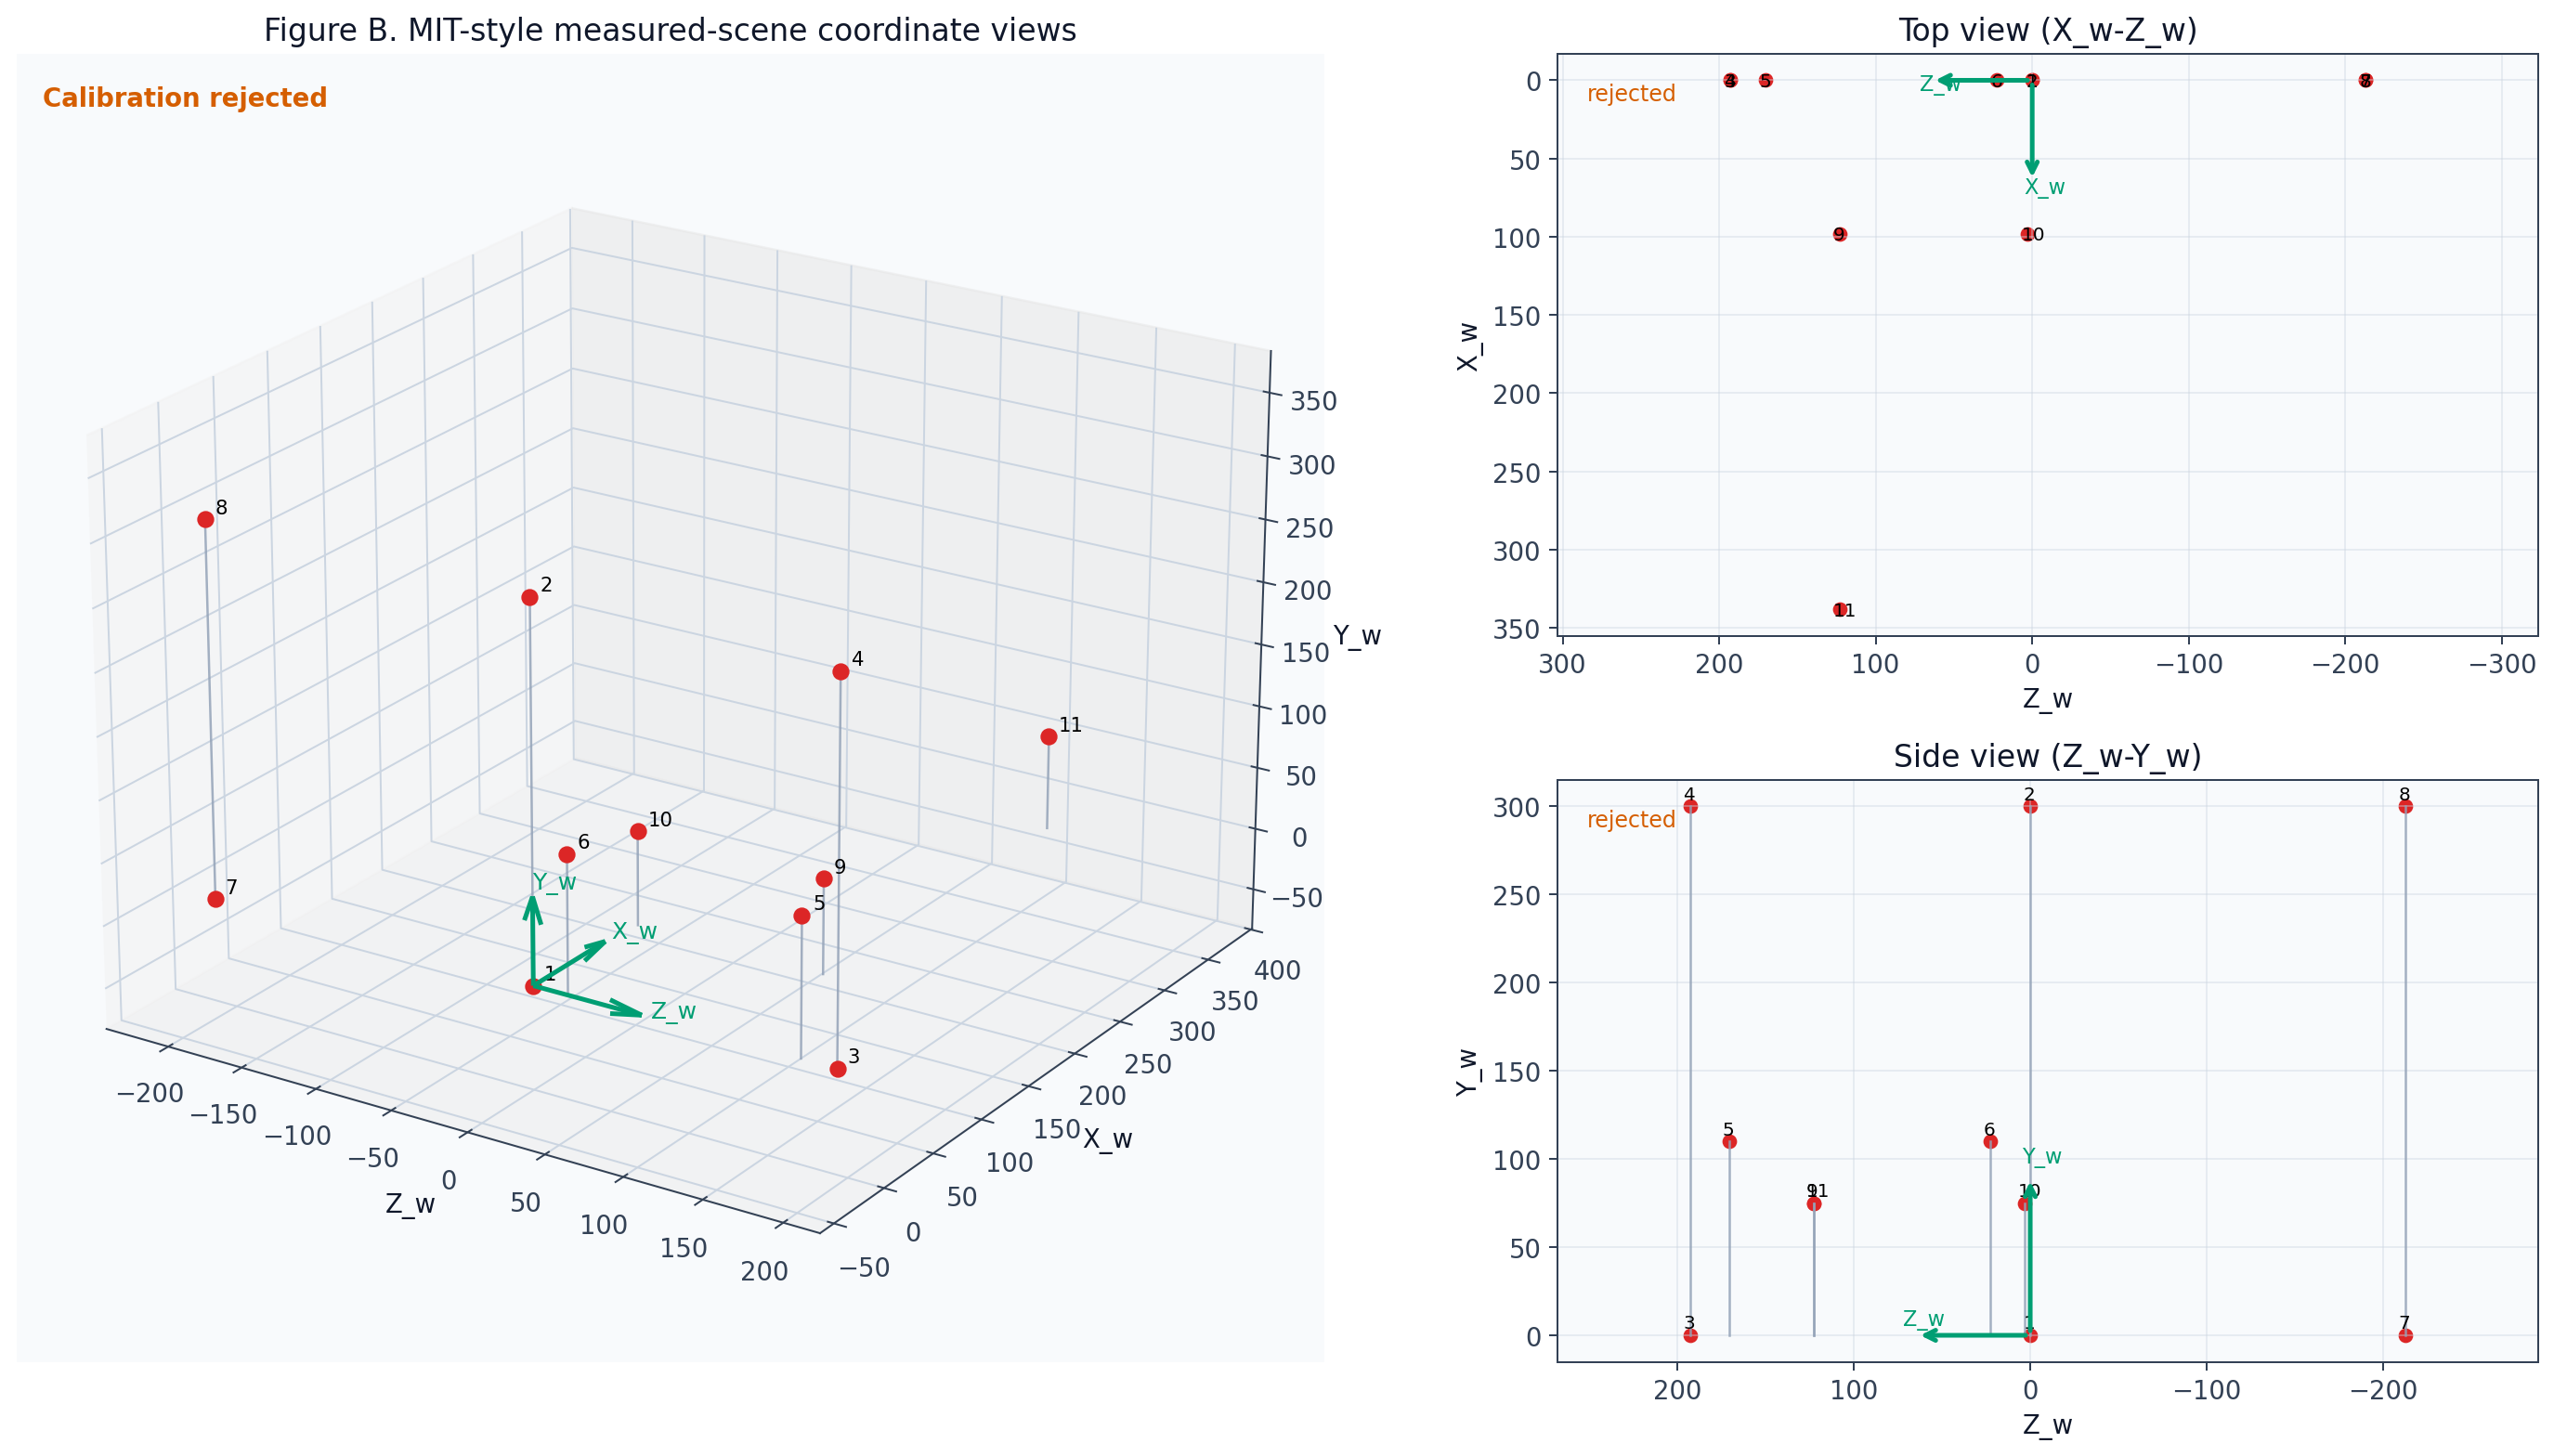

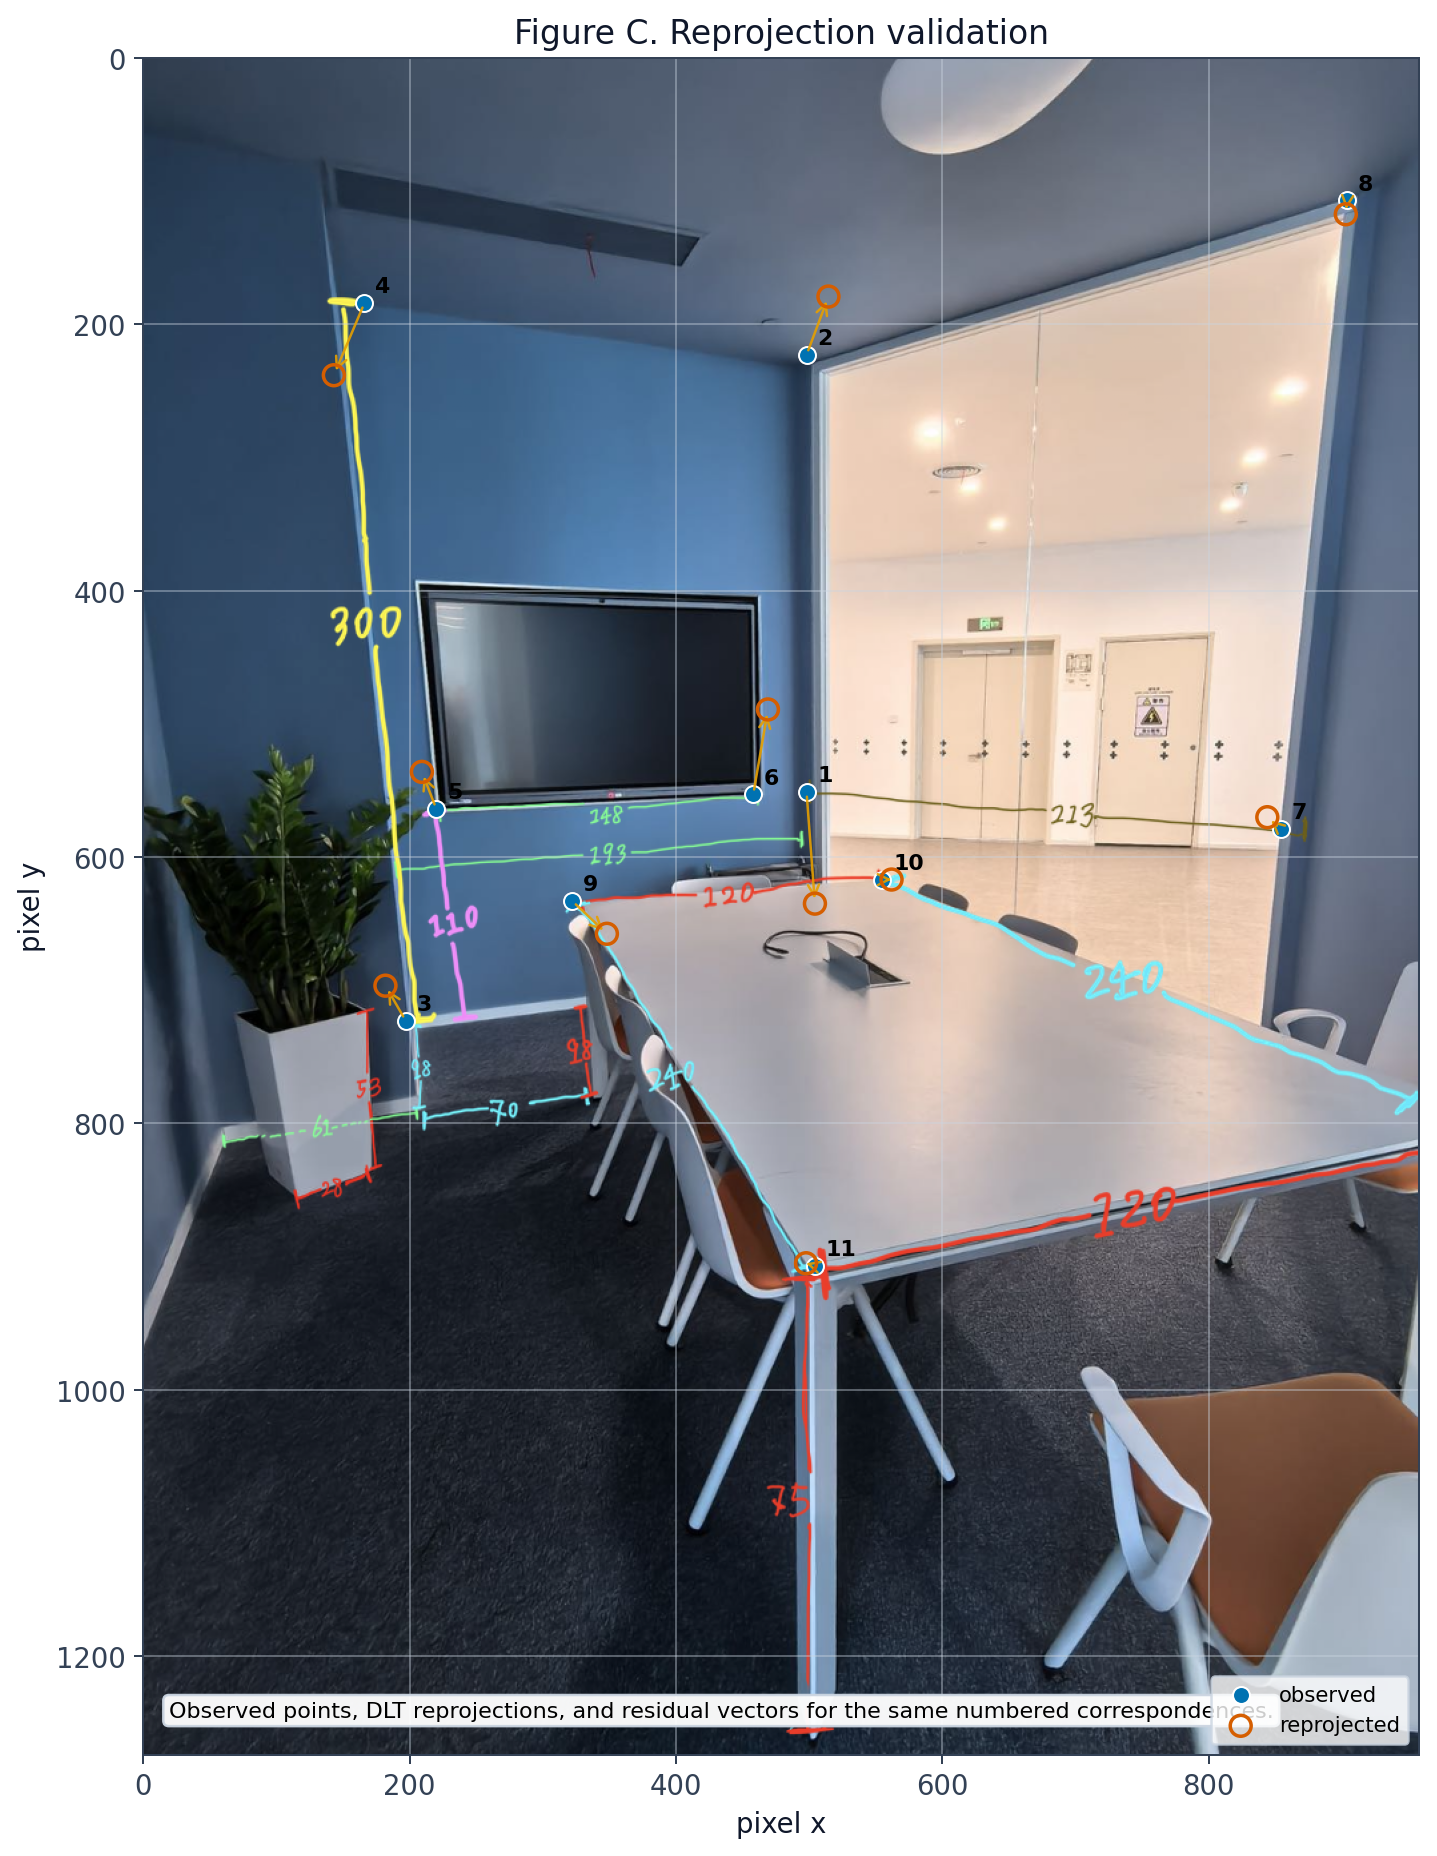

Per-point reprojection summary:


i,"observed (x_i, y_i)","predicted (x_i, y_i)",fit error (px),leave-one-out error (px)
1,"(498.0, 551.0)","(504.3, 635.0)",84.26,117.53
2,"(498.0, 223.0)","(514.5, 179.1)",46.85,70.79
3,"(197.0, 723.0)","(181.8, 696.6)",30.43,57.05
4,"(166.0, 184.0)","(143.0, 238.2)",58.88,136.73
5,"(220.0, 564.0)","(209.2, 536.1)",29.95,42.19
6,"(458.0, 553.0)","(469.0, 489.2)",64.73,77.09
7,"(854.0, 579.0)","(844.0, 570.1)",13.35,90.60
8,"(904.0, 107.0)","(903.0, 117.3)",10.39,75.71
9,"(322.0, 633.0)","(348.1, 657.7)",35.91,99.86
10,"(555.0, 617.0)","(561.8, 616.9)",6.85,11.39


Largest-error point: 1 with 84.26 px. A plausible cause is the combination of manual pixel selection, lens distortion, and simplified axis-aligned scene geometry.


In [7]:
annotated_image_path = CHAPTER_DIR / "biaoding.jpg"
assert annotated_image_path.exists(), f"Missing annotated meeting-room image: {annotated_image_path}"

image = plt.imread(annotated_image_path)
image_height, image_width = image.shape[:2]

wall_height = 300.0
wall_span_z = 193.0
opening_width = 213.0

tv_width = 148.0
tv_bottom_height = 110.0
tv_right_gap = (wall_span_z - tv_width) / 2.0
tv_left_z = tv_right_gap + tv_width
tv_right_z = tv_right_gap

table_back_left_z = wall_span_z - 70.0
table_back_right_z = table_back_left_z - 120.0
table_back_x = 98.0
table_front_x = 98.0 + 240.0
table_top_height = 75.0

origin_floor = (0.0, 0.0, 0.0)
origin_ceiling = (0.0, wall_height, 0.0)
left_wall_floor = (0.0, 0.0, wall_span_z)
left_wall_ceiling = (0.0, wall_height, wall_span_z)
TV_lower_left = (0.0, tv_bottom_height, tv_left_z)
TV_lower_right = (0.0, tv_bottom_height, tv_right_z)
opening_right_floor = (0.0, 0.0, -opening_width)
opening_right_ceiling = (0.0, wall_height, -opening_width)
table_back_left = (table_back_x, table_top_height, table_back_left_z)
table_back_right = (table_back_x, table_top_height, table_back_right_z)
table_front_left = (table_front_x, table_top_height, table_back_left_z)
table_front_right = (table_front_x, table_top_height, table_back_right_z)

print("World coordinate convention for the measured scene:")
print("- Origin O = opening-left floor corner = (0, 0, 0)")
print("- +Y_w points upward along the opening-left jamb")
print("- +Z_w points leftward along the blue wall toward the TV and plant")
print("- +X_w points outward into the room toward the photographer")
print("- blue wall: X_w = 0")
print("- floor: Y_w = 0")
print("- table top: Y_w = 75 cm")

measurement_rows = [
    {"measurement": "Blue-wall span from the yellow wall reference to the opening origin", "value_cm": wall_span_z, "source segment": "Green 193 cm wall annotation", "status": "direct"},
    {"measurement": "Wall / opening height", "value_cm": wall_height, "source segment": "Yellow 300 cm vertical annotation", "status": "direct"},
    {"measurement": "Opening width to the right of the origin", "value_cm": opening_width, "source segment": "Brown 213 cm opening annotation", "status": "direct"},
    {"measurement": "Television width", "value_cm": tv_width, "source segment": "Green 148 cm annotation along the TV lower edge", "status": "direct"},
    {"measurement": "Television bottom height", "value_cm": tv_bottom_height, "source segment": "Magenta 110 cm annotation", "status": "direct"},
    {"measurement": "Television right gap inside the 193 cm wall span", "value_cm": tv_right_gap, "source segment": "Derived as (193 - 148) / 2 because the TV is centered in the measured wall span", "status": "derived"},
    {"measurement": "Television lower-left Z_w coordinate", "value_cm": tv_left_z, "source segment": "Derived as 22.5 + 148.0 because +Z_w points leftward", "status": "derived"},
    {"measurement": "Television lower-right Z_w coordinate", "value_cm": tv_right_z, "source segment": "Derived as the centered 22.5 cm right gap", "status": "derived"},
    {"measurement": "Table back-edge distance from the wall", "value_cm": table_back_x, "source segment": "Red 98 cm floor-depth annotation", "status": "direct"},
    {"measurement": "Table length along +X_w", "value_cm": 240.0, "source segment": "Cyan 240 cm long-edge annotation", "status": "direct"},
    {"measurement": "Table width along Z_w", "value_cm": 120.0, "source segment": "Red 120 cm width annotation", "status": "direct"},
    {"measurement": "Table top height", "value_cm": table_top_height, "source segment": "Red 75 cm vertical annotation at the visible front leg", "status": "direct"},
    {"measurement": "Table back-left Z_w coordinate", "value_cm": table_back_left_z, "source segment": "Derived as 193.0 - 70.0 from the cyan 70 cm wall-direction annotation", "status": "derived"},
    {"measurement": "Table back-right Z_w coordinate", "value_cm": table_back_right_z, "source segment": "Derived as 123.0 - 120.0 because the table width extends toward the opening", "status": "derived"},
    {"measurement": "Table front-edge X_w coordinate", "value_cm": table_front_x, "source segment": "Derived as 98.0 + 240.0 along the table length direction", "status": "derived"},
]

excluded_measurements = [
    "The TV upper corners were excluded because the photograph does not provide an independently measured television height.",
    "The plant annotations 61 cm, 53 cm, and 28 cm were excluded because the planter corners are partially occluded and not reliable calibration points.",
    "The cyan 48 cm annotation was excluded because its upper endpoint is not an unambiguous architectural corner.",
]

print("Measurement table used for the meeting-room model (centimeters):")
render_html_table(measurement_rows, ["measurement", "value_cm", "source segment", "status"])
print("Excluded or ambiguous measurements:")
for item in excluded_measurements:
    print(f"- {item}")

candidate_points = [
    {"i": 1, "feature": "origin wall/opening/floor corner", "world": origin_floor, "pixel": (498.0, 551.0), "measurement source": "architectural origin at the left opening jamb", "direct / derived": "direct", "retained / excluded": "retained", "reason": "verified"},
    {"i": 2, "feature": "origin ceiling corner", "world": origin_ceiling, "pixel": (498.0, 223.0), "measurement source": "same opening jamb, extended upward by the 300 cm wall height", "direct / derived": "derived", "retained / excluded": "retained", "reason": "verified"},
    {"i": 3, "feature": "left wall floor point", "world": left_wall_floor, "pixel": (197.0, 723.0), "measurement source": "yellow-reference wall/floor point plus the measured 193 cm wall span", "direct / derived": "derived", "retained / excluded": "retained", "reason": "verified"},
    {"i": 4, "feature": "left wall ceiling point", "world": left_wall_ceiling, "pixel": (166.0, 184.0), "measurement source": "yellow-reference wall/ceiling point plus the measured 193 cm wall span", "direct / derived": "derived", "retained / excluded": "retained", "reason": "verified"},
    {"i": 5, "feature": "TV lower-left corner", "world": TV_lower_left, "pixel": (220.0, 564.0), "measurement source": "centered 148 cm TV width inside the 193 cm wall span", "direct / derived": "derived", "retained / excluded": "retained", "reason": "verified"},
    {"i": 6, "feature": "TV lower-right corner", "world": TV_lower_right, "pixel": (458.0, 553.0), "measurement source": "centered 148 cm TV width inside the 193 cm wall span", "direct / derived": "derived", "retained / excluded": "retained", "reason": "verified"},
    {"i": 7, "feature": "opening-right floor corner", "world": opening_right_floor, "pixel": (854.0, 579.0), "measurement source": "architectural opening corner at the right jamb and floor", "direct / derived": "direct", "retained / excluded": "retained", "reason": "verified"},
    {"i": 8, "feature": "opening-right ceiling corner", "world": opening_right_ceiling, "pixel": (904.0, 107.0), "measurement source": "architectural opening corner at the right jamb and ceiling", "direct / derived": "direct", "retained / excluded": "retained", "reason": "verified"},
    {"i": 9, "feature": "table back-left top corner", "world": table_back_left, "pixel": (322.0, 633.0), "measurement source": "axis-aligned table model derived from the annotated 98, 240, 70, 120, and 75 cm measurements", "direct / derived": "derived", "retained / excluded": "retained", "reason": "verified"},
    {"i": 10, "feature": "table back-right top corner", "world": table_back_right, "pixel": (555.0, 617.0), "measurement source": "axis-aligned table model derived from the annotated 98, 240, 70, 120, and 75 cm measurements", "direct / derived": "derived", "retained / excluded": "retained", "reason": "verified"},
    {"i": 11, "feature": "table front-left top corner", "world": table_front_left, "pixel": (504.0, 907.0), "measurement source": "axis-aligned table model derived from the annotated 98, 240, 70, 120, and 75 cm measurements", "direct / derived": "derived", "retained / excluded": "retained", "reason": "verified"},
    {"i": 12, "feature": "table front-right top corner", "world": table_front_right, "pixel": None, "measurement source": "axis-aligned table model derived from the annotated 98, 240, 70, 120, and 75 cm measurements", "direct / derived": "derived", "retained / excluded": "excluded", "reason": "outside the image; exact physical corner cannot be visually verified"},
]

assert len({row["i"] for row in candidate_points}) == len(candidate_points), "Point IDs must be unique."
assert candidate_points[0]["world"] == (0.0, 0.0, 0.0), "Origin must be exactly (0, 0, 0)."

for row in candidate_points:
    world = np.asarray(row["world"], dtype=np.float64)
    assert np.all(np.isfinite(world)), f"World coordinates must be finite for point {row['i']}"
    if row["retained / excluded"] == "retained":
        pixel = np.asarray(row["pixel"], dtype=np.float64)
        assert np.all(np.isfinite(pixel)), f"Pixel coordinates must be finite for retained point {row['i']}"
        assert 0.0 <= pixel[0] < image_width and 0.0 <= pixel[1] < image_height, f"Retained point {row['i']} must lie inside the image."

wall_point_ids = {1, 2, 3, 4, 5, 6, 7, 8}
floor_point_ids = {1, 3, 7}
table_top_ids = {9, 10, 11, 12}
for row in candidate_points:
    X_i, Y_i, Z_i = row["world"]
    if row["i"] in wall_point_ids:
        assert abs(X_i) < 1e-9, f"Wall point {row['i']} must satisfy X_w = 0"
    if row["i"] in floor_point_ids:
        assert abs(Y_i) < 1e-9, f"Floor point {row['i']} must satisfy Y_w = 0"
    if row["i"] in table_top_ids:
        assert abs(Y_i - 75.0) < 1e-9, f"Table-top point {row['i']} must satisfy Y_w = 75"

retained_points = [row for row in candidate_points if row["retained / excluded"] == "retained"]
excluded_points = [row for row in candidate_points if row["retained / excluded"] == "excluded"]

print("Point-by-point visual audit:")
for row in candidate_points:
    label = "verified" if row["retained / excluded"] == "retained" else f"excluded ({row['reason']})"
    print(f"Point {row['i']}: {row['feature']} — {label}")

print("Retained point IDs:", [row["i"] for row in retained_points])
print("Excluded point IDs:", [row["i"] for row in excluded_points])

audit_rows = []
for row in candidate_points:
    X_i, Y_i, Z_i = row["world"]
    if row["pixel"] is None:
        x_i = "-"
        y_i = "-"
    else:
        x_i = f"{row['pixel'][0]:.1f}"
        y_i = f"{row['pixel'][1]:.1f}"
    audit_rows.append(
        {
            "i": row["i"],
            "feature": row["feature"],
            "X_i": X_i,
            "Y_i": Y_i,
            "Z_i": Z_i,
            "x_i": x_i,
            "y_i": y_i,
            "measurement source": row["measurement source"],
            "direct / derived": row["direct / derived"],
            "retained / excluded": row["retained / excluded"],
        }
    )
print("Audited correspondence table:")
render_html_table(
    audit_rows,
    ["i", "feature", "X_i", "Y_i", "Z_i", "x_i", "y_i", "measurement source", "direct / derived", "retained / excluded"],
)

world_points_real = np.asarray([row["world"] for row in retained_points], dtype=np.float64)
image_points_real = np.asarray([row["pixel"] for row in retained_points], dtype=np.float64)
point_numbers = [row["i"] for row in retained_points]
point_features = [row["feature"] for row in retained_points]

assert world_points_real.shape[0] == image_points_real.shape[0], "3D and 2D arrays must contain the same number of retained points."
assert world_points_real.shape[0] == len(point_numbers), "Point ordering must be identical across all retained lists."
assert np.all(np.isfinite(world_points_real)) and np.all(np.isfinite(image_points_real)), "All retained coordinates must be finite."

supporting_planes = set()
if np.any(np.isclose(world_points_real[:, 0], 0.0)):
    supporting_planes.add("blue wall (X_w = 0)")
if np.any(np.isclose(world_points_real[:, 1], 0.0)):
    supporting_planes.add("floor (Y_w = 0)")
if np.any(np.isclose(world_points_real[:, 1], 75.0)):
    supporting_planes.add("table top (Y_w = 75)")

_, singular_values, _ = np.linalg.svd(world_points_real - world_points_real.mean(axis=0), full_matrices=False)
coordinate_rank = int(np.sum(singular_values > 1e-6))
projection_real, dlt_matrix = estimate_projection_matrix_normalized_dlt(world_points_real, image_points_real)
dlt_rank = int(np.linalg.matrix_rank(dlt_matrix))
reprojected_points = project_with_projection_matrix(world_points_real, projection_real)
reprojection_error = np.linalg.norm(reprojected_points - image_points_real, axis=1)
mean_error = float(reprojection_error.mean())
median_error = float(np.median(reprojection_error))
rms_error = float(np.sqrt(np.mean(reprojection_error ** 2)))
max_error = float(reprojection_error.max())
worst_index = int(np.argmax(reprojection_error))
worst_point_id = point_numbers[worst_index]

intrinsics_raw, rotation_raw, translation_raw, camera_center_raw = decompose_projection_matrix(projection_real)
sign_matrix_report = np.diag(
    [
        -1.0 if intrinsics_raw[0, 0] < 0.0 else 1.0,
        -1.0 if intrinsics_raw[1, 1] < 0.0 else 1.0,
        1.0,
    ]
)
intrinsics_real = intrinsics_raw @ sign_matrix_report
rotation_real = sign_matrix_report @ rotation_raw
translation_real = np.linalg.solve(intrinsics_real, projection_real[:, 3])
camera_center_real = camera_center_raw.copy()
rotation_det = float(np.linalg.det(rotation_real))
orthogonality_error = float(np.linalg.norm(rotation_real @ rotation_real.T - np.eye(3), ord="fro"))
view_direction_world = rotation_real.T @ np.array([0.0, 0.0, 1.0], dtype=np.float64)
view_direction_world = view_direction_world / np.linalg.norm(view_direction_world)
camera_space_points = (rotation_real @ (world_points_real.T - camera_center_real[:, None])).T
camera_depth_values = camera_space_points[:, 2].copy()
if camera_depth_values.mean() < 0.0:
    view_direction_world = -view_direction_world
    camera_depth_values = -camera_depth_values
positive_depth_ratio = float(np.mean(camera_depth_values > 0.0))

leave_one_out_errors = []
for holdout_index in range(len(retained_points)):
    train_mask = np.ones(len(retained_points), dtype=bool)
    train_mask[holdout_index] = False
    projection_loo, _ = estimate_projection_matrix_normalized_dlt(world_points_real[train_mask], image_points_real[train_mask])
    predicted_holdout = project_with_projection_matrix(world_points_real[[holdout_index]], projection_loo)[0]
    leave_one_out_errors.append(float(np.linalg.norm(predicted_holdout - image_points_real[holdout_index])))
leave_one_out_errors = np.asarray(leave_one_out_errors, dtype=np.float64)

principal_point = (float(intrinsics_real[0, 2]), float(intrinsics_real[1, 2]))
fx_est = float(intrinsics_real[0, 0])
fy_est = float(intrinsics_real[1, 1])
camera_center_x, camera_center_y, camera_center_z = [float(value) for value in camera_center_real]

camera_checks = {
    "enough_points": len(retained_points) >= 6,
    "noncoplanar": coordinate_rank >= 3,
    "full_rank_dlt": dlt_rank >= 11,
    "principal_point_inside_image": 0.0 <= principal_point[0] <= image_width and 0.0 <= principal_point[1] <= image_height,
    "positive_focal_lengths": fx_est > 0.0 and fy_est > 0.0,
    "camera_in_front_of_wall": camera_center_x > 0.0,
    "camera_height_plausible": 80.0 <= camera_center_y <= 220.0,
    "camera_depth_plausible": -80.0 <= camera_center_z <= 260.0,
    "view_direction_into_room": view_direction_world[0] > 0.0,
    "positive_depth_ratio": positive_depth_ratio >= 0.9,
    "reprojection_error_reasonable": mean_error <= 20.0 and max_error <= 50.0,
    "leave_one_out_stable": float(np.mean(leave_one_out_errors)) <= 60.0 and float(np.max(leave_one_out_errors)) <= 150.0,
    "rotation_proper": abs(rotation_det - 1.0) <= 1e-3,
    "rotation_orthogonal": orthogonality_error <= 1e-6,
}
calibration_accepted = all(camera_checks.values())

print("Correspondence diagnostics:")
print(f"- Number of retained points: {len(retained_points)}")
print(f"- Distinct supporting planes: {len(supporting_planes)} ({', '.join(sorted(supporting_planes))})")
print(f"- 3D coordinate rank: {coordinate_rank}")
print(f"- DLT design-matrix rank: {dlt_rank}")
print(
    "- Coordinate ranges (cm): "
    f"X_w in [{world_points_real[:, 0].min():.1f}, {world_points_real[:, 0].max():.1f}], "
    f"Y_w in [{world_points_real[:, 1].min():.1f}, {world_points_real[:, 1].max():.1f}], "
    f"Z_w in [{world_points_real[:, 2].min():.1f}, {world_points_real[:, 2].max():.1f}]"
)
print("Estimated 3x4 projection matrix (normalized DLT):")
print(np.array2string(projection_real, formatter={"float_kind": lambda value: f"{value:10.4f}"}))
print("Recovered camera factors:")
print(np.array2string(intrinsics_real, formatter={"float_kind": lambda value: f"{value:10.4f}"}))
print(np.array2string(rotation_real, formatter={"float_kind": lambda value: f"{value:10.4f}"}))
print(f"translation vector t = {np.array2string(translation_real, formatter={'float_kind': lambda value: f'{value:10.4f}'})}")
print(f"camera center C = {np.array2string(camera_center_real, formatter={'float_kind': lambda value: f'{value:10.2f}'})} cm")
print(f"rotation determinant = {rotation_det:.6f}")
print(f"rotation orthogonality error = {orthogonality_error:.6e}")
print(f"estimated focal lengths: fx = {fx_est:.2f}, fy = {fy_est:.2f}")
print(f"estimated principal point = ({principal_point[0]:.2f}, {principal_point[1]:.2f})")
print(f"positive-depth ratio = {(camera_depth_values > 0.0).sum()} / {len(retained_points)} ({100.0 * positive_depth_ratio:.1f}%)")
print(
    f"reprojection error = mean {mean_error:.2f} px, median {median_error:.2f} px, "
    f"RMS {rms_error:.2f} px, max {max_error:.2f} px"
)
print(
    f"leave-one-out error = mean {float(np.mean(leave_one_out_errors)):.2f} px, "
    f"median {float(np.median(leave_one_out_errors)):.2f} px, max {float(np.max(leave_one_out_errors)):.2f} px"
)
print("Camera plausibility checks:")
for key, value in camera_checks.items():
    print(f"- {key}: {value}")
if calibration_accepted:
    print("Calibration accepted: measured correspondences support a physically plausible camera pose.")
else:
    print("Calibration rejected: measured correspondences do not yet support")
    print("a physically plausible camera pose.")

coordinate_rows = []
for row in retained_points:
    X_i, Y_i, Z_i = row["world"]
    x_i, y_i = row["pixel"]
    coordinate_rows.append((row["i"], X_i, Y_i, Z_i, x_i, y_i))

photo_axis_origin = np.asarray(candidate_points[0]["pixel"], dtype=np.float64)
photo_axis_vectors = {
    "Y_w": np.array([0.0, -105.0]),
    "Z_w": np.array([-92.0, 0.0]),
    "X_w": np.array([96.0, 62.0]),
}

fig, (ax_img, ax_tbl) = plt.subplots(
    1,
    2,
    figsize=(16.0, 9.6),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1.35, 0.95]},
)
ax_img.imshow(image)
ax_img.set_title("Figure A. MIT-style measured-scene correspondences: photograph and coordinate table")
ax_img.set_xlabel("pixel x")
ax_img.set_ylabel("pixel y")
for row in retained_points:
    x_i, y_i = row["pixel"]
    ax_img.scatter([x_i], [y_i], s=58, color="#dc2626", edgecolors="white", linewidths=0.9, zorder=4)
    ax_img.text(x_i + 8.0, y_i - 8.0, str(row["i"]), color="black", fontsize=9.2, fontweight="bold", zorder=5)
for axis_name, delta in photo_axis_vectors.items():
    ax_img.annotate(
        "",
        xy=(photo_axis_origin[0] + delta[0], photo_axis_origin[1] + delta[1]),
        xytext=(photo_axis_origin[0], photo_axis_origin[1]),
        arrowprops=dict(arrowstyle="->", lw=2.2, color=COLORS["green"]),
    )
    ax_img.text(
        photo_axis_origin[0] + delta[0] + (5.0 if axis_name != "Z_w" else -22.0),
        photo_axis_origin[1] + delta[1] + (-6.0 if axis_name == "Y_w" else 8.0),
        axis_name,
        color=COLORS["green"],
        fontsize=10.0,
        fontweight="bold",
    )
ax_img.set_xlim(0, image_width)
ax_img.set_ylim(image_height, 0)

ax_tbl.axis("off")
header = "i | X_i | Y_i | Z_i | x_i | y_i"
lines = [header, "-" * len(header)]
for row in coordinate_rows:
    i_val, X_i, Y_i, Z_i, x_i, y_i = row
    lines.append(f"{i_val:>2d} | {X_i:>5.1f} | {Y_i:>5.1f} | {Z_i:>6.1f} | {x_i:>5.1f} | {y_i:>5.1f}")
ax_tbl.text(0.0, 1.0, "\n".join(lines), ha="left", va="top", fontsize=11.0, family="monospace", linespacing=1.45)
savefig(fig, "personal-mit-style-upper-layout")

plot_points = []
for row in retained_points:
    X_w, Y_w, Z_w = row["world"]
    plot_points.append({
        "i": row["i"],
        "plot_x": Z_w,
        "plot_y": X_w,
        "plot_z": Y_w,
        "world": row["world"],
    })

fig = plt.figure(figsize=(15.8, 8.6), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[1.55, 1.0], height_ratios=[1.0, 1.0])
ax3d = fig.add_subplot(gs[:, 0], projection="3d")
axtop = fig.add_subplot(gs[0, 1])
axside = fig.add_subplot(gs[1, 1])

for row in plot_points:
    px = row["plot_x"]
    py = row["plot_y"]
    pz = row["plot_z"]
    ax3d.plot([px, px], [py, py], [0.0, pz], color="#94a3b8", linewidth=1.0, alpha=0.85)
    ax3d.scatter([px], [py], [pz], color="#dc2626", s=40, depthshade=False)
    ax3d.text(px + 4.0, py + 4.0, pz + 4.0, str(row["i"]), color="black", fontsize=8.5)
axis_scale = 70.0
ax3d.quiver(0.0, 0.0, 0.0, axis_scale, 0.0, 0.0, color=COLORS["green"], linewidth=2.0)
ax3d.quiver(0.0, 0.0, 0.0, 0.0, axis_scale, 0.0, color=COLORS["green"], linewidth=2.0)
ax3d.quiver(0.0, 0.0, 0.0, 0.0, 0.0, axis_scale, color=COLORS["green"], linewidth=2.0)
ax3d.text(axis_scale + 6.0, 0.0, 0.0, "Z_w", color=COLORS["green"], fontsize=10.0)
ax3d.text(0.0, axis_scale + 6.0, 0.0, "X_w", color=COLORS["green"], fontsize=10.0)
ax3d.text(0.0, 0.0, axis_scale + 6.0, "Y_w", color=COLORS["green"], fontsize=10.0)
if calibration_accepted:
    cam_plot = np.array([camera_center_real[2], camera_center_real[0], camera_center_real[1]], dtype=np.float64)
    cam_dir_plot = np.array([view_direction_world[2], view_direction_world[0], view_direction_world[1]], dtype=np.float64)
    ax3d.scatter([cam_plot[0]], [cam_plot[1]], [cam_plot[2]], color=COLORS["blue"], s=72, marker="^", depthshade=False)
    ax3d.quiver(cam_plot[0], cam_plot[1], cam_plot[2], cam_dir_plot[0], cam_dir_plot[1], cam_dir_plot[2], length=90.0, color=COLORS["blue"], linewidth=2.0)
    ax3d.text(cam_plot[0] + 6.0, cam_plot[1] + 6.0, cam_plot[2] + 6.0, "camera", color=COLORS["blue"], fontsize=9.0)
else:
    ax3d.text2D(0.02, 0.96, "Calibration rejected", transform=ax3d.transAxes, color=COLORS["vermillion"], fontsize=11.0, fontweight="bold")
ax3d.set_title("Figure B. MIT-style measured-scene coordinate views")
ax3d.set_xlabel("Z_w")
ax3d.set_ylabel("X_w")
ax3d.set_zlabel("Y_w")
ax3d.view_init(elev=22, azim=-57)
set_axes_equal(ax3d)

for row in retained_points:
    X_w, Y_w, Z_w = row["world"]
    axtop.scatter([Z_w], [X_w], color="#dc2626", s=28)
    axtop.text(Z_w + 4.0, X_w + 4.0, str(row["i"]), color="black", fontsize=8.0)
axtop.annotate("", xy=(65.0, 0.0), xytext=(0.0, 0.0), arrowprops=dict(arrowstyle="->", lw=2.0, color=COLORS["green"]))
axtop.annotate("", xy=(0.0, 65.0), xytext=(0.0, 0.0), arrowprops=dict(arrowstyle="->", lw=2.0, color=COLORS["green"]))
axtop.text(72.0, 6.0, "Z_w", color=COLORS["green"], fontsize=9.0)
axtop.text(5.0, 72.0, "X_w", color=COLORS["green"], fontsize=9.0)
if calibration_accepted:
    axtop.scatter([camera_center_real[2]], [camera_center_real[0]], color=COLORS["blue"], s=45, marker="^")
    axtop.quiver(camera_center_real[2], camera_center_real[0], view_direction_world[2], view_direction_world[0], angles="xy", scale_units="xy", scale=0.02, color=COLORS["blue"], width=0.004)
else:
    axtop.text(0.03, 0.95, "rejected", transform=axtop.transAxes, color=COLORS["vermillion"], fontsize=9.5, ha="left", va="top")
axtop.set_title("Top view (X_w-Z_w)")
axtop.set_xlabel("Z_w")
axtop.set_ylabel("X_w")
light_grid(axtop)
axtop.invert_xaxis()
axtop.invert_yaxis()
axtop.axis("equal")

for row in retained_points:
    X_w, Y_w, Z_w = row["world"]
    axside.plot([Z_w, Z_w], [0.0, Y_w], color="#94a3b8", linewidth=1.0, alpha=0.85)
    axside.scatter([Z_w], [Y_w], color="#dc2626", s=28)
    axside.text(Z_w + 4.0, Y_w + 4.0, str(row["i"]), color="black", fontsize=8.0)
axside.annotate("", xy=(65.0, 0.0), xytext=(0.0, 0.0), arrowprops=dict(arrowstyle="->", lw=2.0, color=COLORS["green"]))
axside.annotate("", xy=(0.0, 90.0), xytext=(0.0, 0.0), arrowprops=dict(arrowstyle="->", lw=2.0, color=COLORS["green"]))
axside.text(72.0, 6.0, "Z_w", color=COLORS["green"], fontsize=9.0)
axside.text(5.0, 98.0, "Y_w", color=COLORS["green"], fontsize=9.0)
if calibration_accepted:
    axside.scatter([camera_center_real[2]], [camera_center_real[1]], color=COLORS["blue"], s=45, marker="^")
    axside.quiver(camera_center_real[2], camera_center_real[1], view_direction_world[2], view_direction_world[1], angles="xy", scale_units="xy", scale=0.02, color=COLORS["blue"], width=0.004)
else:
    axside.text(0.03, 0.95, "rejected", transform=axside.transAxes, color=COLORS["vermillion"], fontsize=9.5, ha="left", va="top")
axside.set_title("Side view (Z_w-Y_w)")
axside.set_xlabel("Z_w")
axside.set_ylabel("Y_w")
light_grid(axside)
axside.invert_xaxis()
axside.axis("equal")
savefig(fig, "personal-mit-style-lower-layout")

fig, ax = plt.subplots(figsize=(8.2, 10.2), constrained_layout=True)
ax.imshow(image)
ax.scatter(image_points_real[:, 0], image_points_real[:, 1], color=COLORS["blue"], s=46, edgecolors="white", linewidths=0.8, label="observed", zorder=3)
ax.scatter(reprojected_points[:, 0], reprojected_points[:, 1], facecolors="none", edgecolors=COLORS["vermillion"], s=70, linewidths=1.4, label="reprojected", zorder=4)
for row, observed, predicted in zip(retained_points, image_points_real, reprojected_points, strict=True):
    ax.annotate(
        "",
        xy=(predicted[0], predicted[1]),
        xytext=(observed[0], observed[1]),
        arrowprops=dict(arrowstyle="->", lw=1.0, color=COLORS["orange"], alpha=0.9),
    )
    ax.text(observed[0] + 8.0, observed[1] - 8.0, str(row["i"]), color="black", fontsize=8.8, fontweight="bold")
ax.set_title("Figure C. Reprojection validation")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.set_xlim(0, image_width)
ax.set_ylim(image_height, 0)
ax.text(
    0.02,
    0.02,
    "Observed points, DLT reprojections, and residual vectors for the same numbered correspondences.",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=8.9,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cbd5e1", alpha=0.96),
)
light_grid(ax)
ax.legend(loc="lower right", fontsize=8.5)
savefig(fig, "personal-reprojection-validation")

error_rows = []
for row, observed, predicted, error_value, loo_value in zip(retained_points, image_points_real, reprojected_points, reprojection_error, leave_one_out_errors, strict=True):
    error_rows.append(
        {
            "i": row["i"],
            "observed (x_i, y_i)": f"({observed[0]:.1f}, {observed[1]:.1f})",
            "predicted (x_i, y_i)": f"({predicted[0]:.1f}, {predicted[1]:.1f})",
            "fit error (px)": float(error_value),
            "leave-one-out error (px)": float(loo_value),
        }
    )
print("Per-point reprojection summary:")
render_html_table(error_rows, ["i", "observed (x_i, y_i)", "predicted (x_i, y_i)", "fit error (px)", "leave-one-out error (px)"])
print(
    f"Largest-error point: {worst_point_id} with {max_error:.2f} px. "
    "A plausible cause is the combination of manual pixel selection, lens distortion, and simplified axis-aligned scene geometry."
)


## 39.8 Concluding Remarks

The chapter's practical message is simple: a camera model is only useful when it links
geometry, coordinates, and measurable image data. Intrinsics explain how rays become
pixels, extrinsics explain where the camera is, and calibration ties both pieces to real
correspondences.


## Section Coverage

| Section | Topic | Original figures included | Generated visualization | Coverage status |
| --- | --- | --- | --- | --- |
| 39.1 | Introduction | 39.1, 39.2 | None | Covered |
| 39.2 | Homogeneous perspective projection | 39.3 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.2.1 | Parallel projection | None | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.3 | Camera-intrinsic parameters | 39.4, 39.5, 39.6, 39.7 | Inline PyTorch/Matplotlib visualizations | Covered |
| 39.3.1 | From meters to pixels | 39.4, 39.5 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.3.2 | From pixels to rays | 39.6 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.3.3 | Simple calibration method | 39.7 | None | Covered |
| 39.3.4 | Other camera parameters | None | None | Concise coverage |
| 39.4 | Camera-extrinsic parameters | 39.8 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.5 | Full camera model | 39.9 | None | Covered |
| 39.6 | Concrete examples | 39.10, 39.11, 39.12, 39.13 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.7 | Camera calibration | 39.14, 39.15, 39.16, 39.17 | Inline PyTorch/Matplotlib visualization | Covered |
| 39.7.1 | Direct linear transform | None | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.7.2 | Recover intrinsics and extrinsics | None | Explanation only | Concise coverage |
| 39.7.3 | Multiplane calibration | None | Explanation only | Concise coverage |
| 39.7.4 | Reprojection error minimization | 39.14 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.7.5 | Toy example | 39.15, 39.16, 39.17 | Explanation only | Covered |
| 39.8 | Concluding remarks | None | None | Concise coverage |


## Figure Coverage

| Figure | Section | Original included | Generated counterpart | Treatment |
| --- | --- | --- | --- | --- |
| 39.1 | 39.1 | Yes | None | Original figure with explanation |
| 39.2 | 39.1 | Yes | None | Original figure with explanation |
| 39.3 | 39.2 | Yes | Inline PyTorch/Matplotlib visualization | Computational reconstruction |
| 39.4 | 39.3.1 | Yes | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.5 | 39.3.1 | Yes | None | Original figure with explanation |
| 39.6 | 39.3.2 | Yes | Inline PyTorch/Matplotlib visualization | Computational reconstruction |
| 39.7 | 39.3.3 | Yes, two panels | None | Original figure with explanation |
| 39.8 | 39.4 | Yes | Inline PyTorch/Matplotlib visualization | Computational reconstruction |
| 39.9 | 39.5 | Yes | None | Original figure with explanation |
| 39.10 | 39.6 | Yes | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.11 | 39.6 | Yes | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.12 | 39.6 | Yes | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.13 | 39.6 | Yes, two panels | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.14 | 39.7.4 | Yes | Inline PyTorch/Matplotlib visualization | Computational reconstruction |
| 39.15 | 39.7.5 | Yes | None | Original figure with explanation |
| 39.16 | 39.7.5 | Yes | None | Original figure with explanation |
| 39.17 | 39.7.5 | Yes | None | Original figure with explanation |


In [8]:
print("Inline generated figures executed successfully in this notebook run.")


Inline generated figures executed successfully in this notebook run.
